In [1]:
import pandas as pd
import numpy as np

In [9]:
df = pd.read_csv("forest_fires_for_analysis_all_nuts_normalised_area.csv")

reminder this is the decade for europe with overlapping of multiple nuts per fire 

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41055 entries, 0 to 41054
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               41055 non-null  int64  
 1   country                          41055 non-null  str    
 2   province                         41055 non-null  str    
 3   commune                          41055 non-null  str    
 4   firedate                         41055 non-null  str    
 5   area_ha                          41055 non-null  int64  
 6   broadleaved_forest_pct           40465 non-null  float64
 7   coniferous_forest_pct            40465 non-null  float64
 8   mixed_forest_pct                 40465 non-null  float64
 9   sclerophyllous_vegetation_pct    40465 non-null  float64
 10  transitional_woodland_shrub_pct  40465 non-null  float64
 11  other_natural_land_cover_pct     40465 non-null  float64
 12  agricultural_areas_pct       

In [11]:
# Create country code from NUTS3 id

df["nuts_country"] = df["nuts3_id"].str[:2]

# Keep only rows where EFFIS country matches NUTS country
df_clean = df[
    df["country"] == df["nuts_country"]
].copy()

# κρατάμε για κάθε fire id το NUTS3 με το μεγαλύτερο overlap area / είναι 1277 σειρές που θα φύγουν
main_nuts3_per_fire = (
    df_clean
    .sort_values("geometry_area_ha", ascending=False)
    .drop_duplicates(subset="id")
    .copy()
)

main_nuts3_per_fire = main_nuts3_per_fire[main_nuts3_per_fire["nuts3_name"].notna()].copy() #we have 4 rows with no matches in nuts we take them out its ok


# Optional check
print("Original rows:", len(df))
print("Rows after country-NUTS match filter:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print("Final rows:", len(main_nuts3_per_fire))

Original rows: 41055
Rows after country-NUTS match filter: 41055
Rows removed: 0
Final rows: 39774


In [12]:
check_mis = df.copy() #check the 205 rows of mismatches

check_mis["nuts_country"] = check_mis["nuts3_id"].str[:2]

mismatches = check_mis[
    check_mis["country"] != check_mis["nuts_country"]
]

mismatches[
    ["country", "province", "commune", "nuts1_name", "nuts2_name", "nuts3_name", "nuts3_id"]
]
mismatches.to_excel("mismatches.xlsx", index=False)
mismatches

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,nuts_country,total_geometry_area_ha,geometry_area_ha_normalized


## Create bigger important category with sizes of fires

In [14]:
# Define fire size categories
bins = [0, 5, 30, 100, 1000, 5000, 10000, float("inf")]

labels = [
    "Very small (<5 ha)",
    "Small (5-30 ha)", #until <30 and then >=30 in the next category
    "Medium (30-100 ha)",
    "Large (100-1,000 ha)",
    "Very large (1,000-5,000 ha)",
    "Extreme (5,000-10,000 ha)",
    "Mega (10,000+ ha)"
]

df["fire_size_category"] = pd.cut(
    df["area_ha"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

df.drop(columns=['nuts_country', 'geometry_area_ha', 'total_geometry_area_ha'], inplace=True)
df

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,natural_vegetation_ha,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,geometry_area_ha_normalized,fire_size_category
0,288077,IT,Salerno,Giffoni Valle Piana,2025-12-31 23:00:00+00:00,2,33.333333,0.0,0.0,0.0,...,1.333333,ITF35,Salerno,intermediate,mountain area,coastal,Campania,Sud,2.0,Very small (<5 ha)
1,288076,IT,Salerno,Giffoni Valle Piana,2025-12-31 23:00:00+00:00,2,0.000000,0.0,0.0,0.0,...,2.000000,ITF35,Salerno,intermediate,mountain area,coastal,Campania,Sud,2.0,Very small (<5 ha)
2,288108,PT,Alto Minho,Gondoriz,2025-12-31 13:12:00+00:00,1,NaN,NaN,NaN,NaN,...,NaN,PT111,Alto Minho,rural,mountain area,coastal,Norte,Continente,1.0,Very small (<5 ha)
3,288112,FR,Cantal,Saint-Cirgues-de-Jordanne,2025-12-31 12:44:00+00:00,5,0.000000,0.0,0.0,0.0,...,5.000000,FRK12,Cantal,rural,mountain area,NaN,Auvergne,Auvergne-Rhône-Alpes,5.0,Small (5-30 ha)
4,288095,FR,Cantal,Saint-Cirgues-de-Jordanne,2025-12-31 11:31:00+00:00,9,16.666667,0.0,0.0,0.0,...,7.500000,FRK12,Cantal,rural,mountain area,NaN,Auvergne,Auvergne-Rhône-Alpes,9.0,Small (5-30 ha)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41050,9109,PT,Alto Tâmega,"Cambeses do Rio, Donões e Mourilhe",2015-01-24 23:00:00+00:00,179,1.117318,0.0,0.0,0.0,...,151.000000,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,179.0,"Large (100-1,000 ha)"
41051,9195,PT,Alto Tâmega,Montalegre e Padroso,2015-01-24 23:00:00+00:00,51,3.773585,0.0,0.0,0.0,...,49.075472,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,51.0,Medium (30-100 ha)
41052,10658,PT,Alto Tâmega,Sezelhe e Covelães,2015-01-24 23:00:00+00:00,210,0.000000,0.0,0.0,0.0,...,203.971292,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,210.0,"Large (100-1,000 ha)"
41053,9363,PT,Alto Tâmega,"Cambeses do Rio, Donões e Mourilhe",2015-01-14 23:00:00+00:00,51,0.000000,0.0,0.0,0.0,...,44.264151,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,51.0,Medium (30-100 ha)


## KEEP FIRE SEASON MONTHS 

Many countries (like France) tend to carry out controlled fires in the winter months (January-March). Burning mostly "other natural land" (ie not dense or not forests) on specific provinces. For this reason we need to keep only the fires in closer to the months of the fire season, April to October.

In [20]:
df['month'].value_counts()

month
March        7544
August       7026
July         5390
February     5272
September    3434
April        3276
January      2268
June         2108
October      1946
May          1158
November     1026
December      607
Name: count, dtype: int64

In [23]:
winter_season = ['January', 'February', 'March', 'November', 'December']
fire_season = ['April', 'May', 'June', 'July', 'August', 'September', 'October']

df_fire_season = df[df['month'].isin(fire_season)]
df_winter_season = df[df['month'].isin(winter_season)]

## Check out the winter season

In [49]:
df_winter_season.to_excel("df_winter_season.xlsx", index=False)
df_winter_season

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,natural_vegetation_ha,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,geometry_area_ha_normalized,fire_size_category
0,288077,IT,Salerno,Giffoni Valle Piana,2025-12-31 23:00:00+00:00,2,33.333333,0.0,0.0,0.0,...,1.333333,ITF35,Salerno,intermediate,mountain area,coastal,Campania,Sud,2.0,Very small (<5 ha)
1,288076,IT,Salerno,Giffoni Valle Piana,2025-12-31 23:00:00+00:00,2,0.000000,0.0,0.0,0.0,...,2.000000,ITF35,Salerno,intermediate,mountain area,coastal,Campania,Sud,2.0,Very small (<5 ha)
2,288108,PT,Alto Minho,Gondoriz,2025-12-31 13:12:00+00:00,1,NaN,NaN,NaN,NaN,...,NaN,PT111,Alto Minho,rural,mountain area,coastal,Norte,Continente,1.0,Very small (<5 ha)
3,288112,FR,Cantal,Saint-Cirgues-de-Jordanne,2025-12-31 12:44:00+00:00,5,0.000000,0.0,0.0,0.0,...,5.000000,FRK12,Cantal,rural,mountain area,NaN,Auvergne,Auvergne-Rhône-Alpes,5.0,Small (5-30 ha)
4,288095,FR,Cantal,Saint-Cirgues-de-Jordanne,2025-12-31 11:31:00+00:00,9,16.666667,0.0,0.0,0.0,...,7.500000,FRK12,Cantal,rural,mountain area,NaN,Auvergne,Auvergne-Rhône-Alpes,9.0,Small (5-30 ha)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41050,9109,PT,Alto Tâmega,"Cambeses do Rio, Donões e Mourilhe",2015-01-24 23:00:00+00:00,179,1.117318,0.0,0.0,0.0,...,151.000000,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,179.0,"Large (100-1,000 ha)"
41051,9195,PT,Alto Tâmega,Montalegre e Padroso,2015-01-24 23:00:00+00:00,51,3.773585,0.0,0.0,0.0,...,49.075472,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,51.0,Medium (30-100 ha)
41052,10658,PT,Alto Tâmega,Sezelhe e Covelães,2015-01-24 23:00:00+00:00,210,0.000000,0.0,0.0,0.0,...,203.971292,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,210.0,"Large (100-1,000 ha)"
41053,9363,PT,Alto Tâmega,"Cambeses do Rio, Donões e Mourilhe",2015-01-14 23:00:00+00:00,51,0.000000,0.0,0.0,0.0,...,44.264151,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,51.0,Medium (30-100 ha)


In [26]:
df_winter_season['fire_size_category'].value_counts()

fire_size_category
Small (5-30 ha)                7441
Medium (30-100 ha)             4080
Very small (<5 ha)             3029
Large (100-1,000 ha)           2049
Very large (1,000-5,000 ha)     107
Extreme (5,000-10,000 ha)         8
Mega (10,000+ ha)                 3
Name: count, dtype: int64

In [28]:
very_large_winter = df_winter_season[df_winter_season['fire_size_category'] == 'Very large (1,000-5,000 ha)']
very_large_winter['country'].value_counts()

country
RO    68
HR    16
ES    13
FR     5
IT     3
BG     1
PT     1
Name: count, dtype: int64

In [37]:
landcover_cols = [
    "broadleaved_forest_ha",
    "coniferous_forest_ha",
    "mixed_forest_ha",
    "sclerophyllous_vegetation_ha",
    "transitional_woodland_shrub_ha",
    "other_natural_land_cover_ha",
    "agricultural_areas_ha",
    "artificial_surfaces_ha",
    "other_land_cover_ha"
]
   
winter_province_summary = (
    df_winter_season.groupby(["province", "country", "month", "year"])[landcover_cols]
      .sum()
      .reset_index()
)

for col in landcover_cols:
    if col in winter_province_summary.columns:
        winter_province_summary[col] = winter_province_summary[col].round(2)

winter_province_summary.to_excel("winter_province_summary.xlsx", index=False)
winter_province_summary

,province,country,month,year,broadleaved_forest_ha,coniferous_forest_ha,mixed_forest_ha,sclerophyllous_vegetation_ha,transitional_woodland_shrub_ha,other_natural_land_cover_ha,agricultural_areas_ha,artificial_surfaces_ha,other_land_cover_ha
0,A Coruña,ES,February,2022,11.00,0.0,0.0,0.0,7.00,27.00,0.00,0.0,0.0
1,A Coruña,ES,February,2023,3.64,0.0,0.0,0.0,0.00,197.36,0.00,0.0,0.0
2,A Coruña,ES,January,2021,0.00,0.0,0.0,0.0,0.00,2.00,0.00,0.0,0.0
3,A Coruña,ES,January,2022,0.00,0.0,0.0,0.0,0.00,76.00,0.00,0.0,0.0
4,A Coruña,ES,January,2023,0.00,0.0,0.0,0.0,0.83,18.17,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2291,Хасково,BG,November,2022,0.00,0.0,0.0,0.0,35.58,210.51,7.91,0.0,0.0
2292,Хасково,BG,November,2024,0.00,0.0,0.0,0.0,4.36,9.64,0.00,0.0,0.0
2293,Шумен,BG,November,2022,0.00,9.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0
2294,Ямбол,BG,February,2020,0.00,0.0,0.0,0.0,0.00,34.48,6.52,0.0,0.0


## Fire season

In [38]:
df_fire_season

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,natural_vegetation_ha,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,geometry_area_ha_normalized,fire_size_category
194,285364,RO,Tulcea,Jurilovca,2025-10-30 23:07:00+00:00,59,0.000000,0.0,0.000000,0.0,...,59.000000,RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,59.0,Medium (30-100 ha)
195,285361,ES,Alicante/Alacant,Elche / Elx,2025-10-30 10:51:00+00:00,7,0.000000,0.0,0.000000,0.0,...,7.000000,ES521,Alicante/Alacant,urban,mountain area,coastal,Comunitat Valenciana,Este,7.0,Small (5-30 ha)
196,285343,BG,Сливен,Котел,2025-10-30 09:32:00+00:00,1,0.000000,0.0,0.000000,0.0,...,1.000000,BG342,Сливен,intermediate,mountain area,NaN,Югоизточен,Северна и Югоизточна България,1.0,Very small (<5 ha)
197,286183,ES,Cantabria,Corvera de Toranzo,2025-10-29 12:23:00+00:00,11,0.000000,0.0,0.000000,0.0,...,11.000000,ES130,Cantabria,intermediate,mountain area,coastal,Cantabria,Noroeste,11.0,Small (5-30 ha)
198,286284,IT,Foggia,Carpino,2025-10-29 10:40:00+00:00,2,0.000000,0.0,0.000000,0.0,...,2.000000,ITF46,Foggia,urban,NaN,coastal,Puglia,Sud,2.0,Very small (<5 ha)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40992,9123,PT,Alto Tâmega,Ardãos e Bobadela,2015-04-02 22:00:00+00:00,103,0.000000,0.0,0.000000,0.0,...,103.000000,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,103.0,"Large (100-1,000 ha)"
40993,319,PT,Área Metropolitana do Porto,Tropeço,2015-04-01 22:00:00+00:00,490,3.271984,0.0,15.337423,0.0,...,354.723926,PT11A,Área Metropolitana do Porto,urban,NaN,coastal,Norte,Continente,490.0,"Large (100-1,000 ha)"
40994,155,PT,Alto Tâmega,Outeiro,2015-04-01 22:00:00+00:00,105,0.000000,0.0,0.000000,0.0,...,105.000000,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,105.0,"Large (100-1,000 ha)"
40995,819,PT,Região de Aveiro,Albergaria-a-Velha e Valmaior,2015-04-01 22:00:00+00:00,1711,8.231173,0.0,0.000000,0.0,...,1481.268535,PT191,Região de Aveiro,intermediate,NaN,coastal,Centro (PT),Continente,1711.0,"Very large (1,000-5,000 ha)"


In [99]:
float_cols = df_fire_season.select_dtypes(include="float").columns

df_fire_season[float_cols] = df_fire_season[float_cols].round(2)

df_fire_season.to_excel(
    "df_fire_season.xlsx",
    index=False
)

In [100]:
df_fire_season

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,natural_vegetation_ha,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,geometry_area_ha_normalized,fire_size_category
194,285364,RO,Tulcea,Jurilovca,2025-10-30 23:07:00+00:00,59,0.00,0.00,0.00,0.00,...,59.00,RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,59.00,Medium (30-100 ha)
195,285361,ES,Alicante/Alacant,Elche / Elx,2025-10-30 10:51:00+00:00,7,0.00,0.00,0.00,0.00,...,7.00,ES521,Alicante/Alacant,urban,mountain area,coastal,Comunitat Valenciana,Este,7.00,Small (5-30 ha)
196,285343,BG,Сливен,Котел,2025-10-30 09:32:00+00:00,1,0.00,0.00,0.00,0.00,...,1.00,BG342,Сливен,intermediate,mountain area,NaN,Югоизточен,Северна и Югоизточна България,1.00,Very small (<5 ha)
197,286183,ES,Cantabria,Corvera de Toranzo,2025-10-29 12:23:00+00:00,11,0.00,0.00,0.00,0.00,...,11.00,ES130,Cantabria,intermediate,mountain area,coastal,Cantabria,Noroeste,11.00,Small (5-30 ha)
198,286284,IT,Foggia,Carpino,2025-10-29 10:40:00+00:00,2,0.00,0.00,0.00,0.00,...,2.00,ITF46,Foggia,urban,NaN,coastal,Puglia,Sud,2.00,Very small (<5 ha)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40992,9123,PT,Alto Tâmega,Ardãos e Bobadela,2015-04-02 22:00:00+00:00,103,0.00,0.00,0.00,0.00,...,103.00,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,103.00,"Large (100-1,000 ha)"
40993,319,PT,Área Metropolitana do Porto,Tropeço,2015-04-01 22:00:00+00:00,490,3.27,0.00,15.34,0.00,...,354.72,PT11A,Área Metropolitana do Porto,urban,NaN,coastal,Norte,Continente,490.00,"Large (100-1,000 ha)"
40994,155,PT,Alto Tâmega,Outeiro,2015-04-01 22:00:00+00:00,105,0.00,0.00,0.00,0.00,...,105.00,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,105.00,"Large (100-1,000 ha)"
40995,819,PT,Região de Aveiro,Albergaria-a-Velha e Valmaior,2015-04-01 22:00:00+00:00,1711,8.23,0.00,0.00,0.00,...,"1,481.27",PT191,Região de Aveiro,intermediate,NaN,coastal,Centro (PT),Continente,"1,711.00","Very large (1,000-5,000 ha)"


# How many fires has EFFIS recorded in the decade?

In [39]:
df_fire_season['id'].nunique()

23391

## How many countries?

In [40]:
df_fire_season['country'].nunique()

26

In [41]:
print(
    f"The dataset contains {df_fire_season['id'].nunique()} unique fires across "
    f"{df_fire_season['country'].nunique()} countries."
)

The dataset contains 23391 unique fires across 26 countries.


## How many fires are more than zero hectares burned?

In [42]:
df_no_zero_ha = df_fire_season[df_fire_season['area_ha'] > 0]
df_no_zero_ha

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,natural_vegetation_ha,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,geometry_area_ha_normalized,fire_size_category
194,285364,RO,Tulcea,Jurilovca,2025-10-30 23:07:00+00:00,59,0.000000,0.0,0.000000,0.0,...,59.000000,RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,59.0,Medium (30-100 ha)
195,285361,ES,Alicante/Alacant,Elche / Elx,2025-10-30 10:51:00+00:00,7,0.000000,0.0,0.000000,0.0,...,7.000000,ES521,Alicante/Alacant,urban,mountain area,coastal,Comunitat Valenciana,Este,7.0,Small (5-30 ha)
196,285343,BG,Сливен,Котел,2025-10-30 09:32:00+00:00,1,0.000000,0.0,0.000000,0.0,...,1.000000,BG342,Сливен,intermediate,mountain area,NaN,Югоизточен,Северна и Югоизточна България,1.0,Very small (<5 ha)
197,286183,ES,Cantabria,Corvera de Toranzo,2025-10-29 12:23:00+00:00,11,0.000000,0.0,0.000000,0.0,...,11.000000,ES130,Cantabria,intermediate,mountain area,coastal,Cantabria,Noroeste,11.0,Small (5-30 ha)
198,286284,IT,Foggia,Carpino,2025-10-29 10:40:00+00:00,2,0.000000,0.0,0.000000,0.0,...,2.000000,ITF46,Foggia,urban,NaN,coastal,Puglia,Sud,2.0,Very small (<5 ha)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40992,9123,PT,Alto Tâmega,Ardãos e Bobadela,2015-04-02 22:00:00+00:00,103,0.000000,0.0,0.000000,0.0,...,103.000000,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,103.0,"Large (100-1,000 ha)"
40993,319,PT,Área Metropolitana do Porto,Tropeço,2015-04-01 22:00:00+00:00,490,3.271984,0.0,15.337423,0.0,...,354.723926,PT11A,Área Metropolitana do Porto,urban,NaN,coastal,Norte,Continente,490.0,"Large (100-1,000 ha)"
40994,155,PT,Alto Tâmega,Outeiro,2015-04-01 22:00:00+00:00,105,0.000000,0.0,0.000000,0.0,...,105.000000,PT11B,Alto Tâmega e Barroso,rural,mountain area,NaN,Norte,Continente,105.0,"Large (100-1,000 ha)"
40995,819,PT,Região de Aveiro,Albergaria-a-Velha e Valmaior,2015-04-01 22:00:00+00:00,1711,8.231173,0.0,0.000000,0.0,...,1481.268535,PT191,Região de Aveiro,intermediate,NaN,coastal,Centro (PT),Continente,1711.0,"Very large (1,000-5,000 ha)"


In [43]:
df_no_zero_ha['id'].nunique()

23176

#### Note: There are 215 fires with zero hectares burned, but in their reports EFFIS is counting them too so we’ll count them in the total number. 

## keep unique fires 

for some reason there are some that are duplicated and have the same exact data..

In [44]:
unique_fires = df_fire_season.drop_duplicates(subset="id")

In [48]:
unique_fires['area_ha'].sum()

np.int64(4534317)

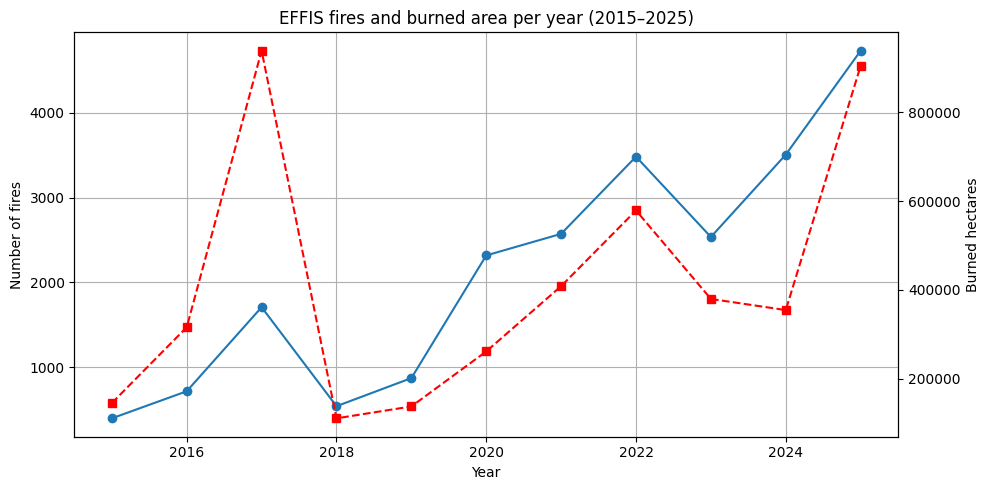

In [45]:
import matplotlib.pyplot as plt

# Fires per year
fires_per_year = (
    unique_fires
    .groupby("year")["id"]
    .count()
    .reset_index(name="fires_count")
    .sort_values("year")
)

# Burned hectares per year
burned_ha_per_year = (
    unique_fires
    .groupby("year")["area_ha"]
    .sum()
    .reset_index(name="burned_ha")
    .sort_values("year")
)

# Create figure
fig, ax1 = plt.subplots(figsize=(10,5))

# Fires line
ax1.plot(
    fires_per_year["year"],
    fires_per_year["fires_count"],
    marker="o",
    label="Number of fires"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Number of fires")

# Second axis for burned hectares
ax2 = ax1.twinx()

ax2.plot(
    burned_ha_per_year["year"],
    burned_ha_per_year["burned_ha"],
    marker="s",
    linestyle="--",
    color="red",
    label="Burned hectares"
)

ax2.set_ylabel("Burned hectares")

# Title
plt.title("EFFIS fires and burned area per year (2015–2025)")

# Grid
ax1.grid(True)

# Layout
fig.tight_layout()

plt.show()

In [46]:
fires_per_year = (
    unique_fires
    .groupby("year")["id"]
    .count()
    .reset_index(name="fires_count")
    .sort_values("year", ascending=False)
)

fires_per_year.to_excel("fires_per_year_fire_season.xlsx", index=False)

fires_per_year

,year,fires_count
10,2025,4730
9,2024,3506
8,2023,2536
7,2022,3482
6,2021,2573
5,2020,2319
4,2019,874
3,2018,543
2,2017,1709
1,2016,719


In [47]:
fires_ha_per_year = (
    unique_fires
    .groupby("year")["area_ha"]
    .sum()
    .reset_index(name="burned_hectares")
    .sort_values("year", ascending=False)
)

fires_ha_per_year.to_excel("fires_ha_per_year_fire_season.xlsx", index=False)

fires_ha_per_year

,year,burned_hectares
10,2025,904922
9,2024,354387
8,2023,379530
7,2022,578953
6,2021,408352
5,2020,261180
4,2019,137145
3,2018,110343
2,2017,939059
1,2016,315657


# How many hectares have been burned in the perio 2015-2025 in Europe?

In [50]:
unique_fires['area_ha'].sum()

np.int64(4534317)

# What are the sizes of the fires through the years? Are extreme fires increasing?

In [51]:
# Count fires per year and category
fires_by_size_year = (
    unique_fires
    .groupby(["year", "fire_size_category"])["id"]
    .count()
    .reset_index(name="fires_count")
)

# Pivot for easier plotting
fires_pivot = fires_by_size_year.pivot(
    index="year",
    columns="fire_size_category",
    values="fires_count"
).fillna(0)

fires_pivot.to_excel("fire_sizes_category_per_year_fire_season.xlsx")
fires_pivot

fire_size_category,Very small (<5 ha),Small (5-30 ha),Medium (30-100 ha),"Large (100-1,000 ha)","Very large (1,000-5,000 ha)","Extreme (5,000-10,000 ha)","Mega (10,000+ ha)"
year,,,,,,,
2015,0.0,16.0,148.0,213.0,19.0,3.0,1.0
2016,0.0,20.0,276.0,356.0,60.0,6.0,1.0
2017,0.0,21.0,824.0,730.0,108.0,13.0,13.0
2018,0.0,74.0,329.0,125.0,13.0,1.0,1.0
2019,0.0,200.0,414.0,245.0,12.0,3.0,0.0
2020,230.0,1025.0,662.0,360.0,37.0,3.0,2.0
2021,390.0,1133.0,588.0,417.0,32.0,7.0,6.0
2022,801.0,1450.0,683.0,463.0,63.0,11.0,11.0
2023,563.0,1123.0,494.0,307.0,40.0,4.0,5.0


## How many recorded fire incidents per country per year?

In [52]:
fires_per_country_year = (
    unique_fires
    .groupby(["country", "year"])["id"]
    .count()
    .reset_index(name="fires_count")
    .sort_values("fires_count", ascending=False)
)
fires_per_country_year.to_excel("fires_per_country_year_fire_season.xlsx", index=False)
fires_per_country_year

,country,year,fires_count
145,IT,2025,1717
141,IT,2021,1348
144,IT,2024,1343
143,IT,2023,1231
142,IT,2022,1176
...,...,...,...
213,SI,2017,1
216,SI,2021,1
215,SI,2020,1
220,SK,2019,1


## IMPORTANT: How many hectares burned per country and per year?

In [53]:
fires_ha_per_country_year = (
    unique_fires
    .groupby(["country", "year"])["area_ha"]
    .sum()
    .reset_index(name="fires_ha")
    .sort_values(["country", "year"], ascending=[True, True])
)

fires_ha_per_country_year.to_excel(
    "fires_ha_per_country_year_fire_season.xlsx",
    index=False
)

fires_ha_per_country_year

,country,year,fires_ha
0,AT,2019,38
1,AT,2020,168
2,AT,2021,82
3,AT,2022,91
4,AT,2024,20
...,...,...,...
220,SK,2019,25
221,SK,2020,107
222,SK,2021,115
223,SK,2022,59


## Which are the largest fires in Europe in the decade?

In [58]:
largest_fires = (
    unique_fires.groupby(
        ["id", "country", "year", "province", "commune", "firedate", "nuts3_name", "nuts2_name", "nuts1_name"],
        as_index=False
    )["area_ha"]
    .max()
    .sort_values("area_ha", ascending=False)
)

largest_fires.head(64)

,id,country,year,province,commune,firedate,nuts3_name,nuts2_name,nuts1_name,area_ha
13927,218736,EL,2023,Έβρος,Τοπική Κοινότητα Δωρικού,2023-08-19 06:39:00+00:00,Έβρος,"Aνατολική Μακεδονία, Θράκη",Βόρεια Ελλάδα,96610
1074,10170,PT,2017,Viseu Dão Lafões,Pinheiro de Ázere,2017-10-13 22:00:00+00:00,Região de Coimbra,Centro (PT),Continente,67521
1134,10293,PT,2017,Região de Coimbra,Lagos da Beira e Lajeosa,2017-10-14 22:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,64321
21482,277926,PT,2025,Beiras e Serra da Estrela,Trancoso (São Pedro e Santa Maria) e Souto Maior,2025-08-10 00:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,62104
12618,213578,EL,2021,Εύβοια,Τοπική Κοινότητα Κουρκουλών,2021-08-03 09:27:23.570000+00:00,Εύβοια,Στερεά Ελλάδα,Κεντρική Ελλάδα,51881
...,...,...,...,...,...,...,...,...,...,...
8532,54081,EL,2021,Δυτική Αττική,Δημοτική Κοινότητα Μάνδρας,2021-08-16 07:35:00+00:00,Δυτική Αττική,Aττική,Αττική,10175
11726,209560,PT,2022,Beiras e Serra da Estrela,Valhelhas,2022-08-15 20:29:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,10126
4069,18351,PT,2019,Médio Tejo,Cardigos,2019-07-19 22:00:00+00:00,Médio Tejo,Oeste e Vale do Tejo,Continente,9924
1510,11511,PT,2017,Viseu Dão Lafões,Campia,2017-10-14 22:00:00+00:00,Região de Aveiro,Centro (PT),Continente,9881


In [59]:
pd.reset_option("display.max_rows")
largest_fires_10000 = (
    largest_fires[
        largest_fires["area_ha"] >= 10000
    ]
)

largest_fires_10000.to_excel(
    "largest_fires_above_10000ha_fire_season.xlsx",
    index=False
)

largest_fires_10000

,id,country,year,province,commune,firedate,nuts3_name,nuts2_name,nuts1_name,area_ha
13927,218736,EL,2023,Έβρος,Τοπική Κοινότητα Δωρικού,2023-08-19 06:39:00+00:00,Έβρος,"Aνατολική Μακεδονία, Θράκη",Βόρεια Ελλάδα,96610
1074,10170,PT,2017,Viseu Dão Lafões,Pinheiro de Ázere,2017-10-13 22:00:00+00:00,Região de Coimbra,Centro (PT),Continente,67521
1134,10293,PT,2017,Região de Coimbra,Lagos da Beira e Lajeosa,2017-10-14 22:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,64321
21482,277926,PT,2025,Beiras e Serra da Estrela,Trancoso (São Pedro e Santa Maria) e Souto Maior,2025-08-10 00:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,62104
12618,213578,EL,2021,Εύβοια,Τοπική Κοινότητα Κουρκουλών,2021-08-03 09:27:23.570000+00:00,Εύβοια,Στερεά Ελλάδα,Κεντρική Ελλάδα,51881
...,...,...,...,...,...,...,...,...,...,...
1540,11573,PT,2017,Beiras e Serra da Estrela,Paços da Serra,2017-10-14 22:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,10701
1725,11942,ES,2017,Huelva,Moguer,2017-06-24 22:00:00+00:00,Huelva,Andalucía,Sur,10375
1887,12221,PT,2017,Médio Tejo,Vila de Rei,2017-08-12 22:00:00+00:00,Médio Tejo,Oeste e Vale do Tejo,Continente,10282
8532,54081,EL,2021,Δυτική Αττική,Δημοτική Κοινότητα Μάνδρας,2021-08-16 07:35:00+00:00,Δυτική Αττική,Aττική,Αττική,10175


In [61]:
pd.reset_option("display.max_rows")
largest_fires_5000 = (
    largest_fires[
        largest_fires["area_ha"] >= 5000
    ]
)

largest_fires_5000.to_excel(
    "largest_fires_above_5000ha_fire_season.xlsx",
    index=False
)

largest_fires_5000

,id,country,year,province,commune,firedate,nuts3_name,nuts2_name,nuts1_name,area_ha
13927,218736,EL,2023,Έβρος,Τοπική Κοινότητα Δωρικού,2023-08-19 06:39:00+00:00,Έβρος,"Aνατολική Μακεδονία, Θράκη",Βόρεια Ελλάδα,96610
1074,10170,PT,2017,Viseu Dão Lafões,Pinheiro de Ázere,2017-10-13 22:00:00+00:00,Região de Coimbra,Centro (PT),Continente,67521
1134,10293,PT,2017,Região de Coimbra,Lagos da Beira e Lajeosa,2017-10-14 22:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,64321
21482,277926,PT,2025,Beiras e Serra da Estrela,Trancoso (São Pedro e Santa Maria) e Souto Maior,2025-08-10 00:00:00+00:00,Beiras e Serra da Estrela,Centro (PT),Continente,62104
12618,213578,EL,2021,Εύβοια,Τοπική Κοινότητα Κουρκουλών,2021-08-03 09:27:23.570000+00:00,Εύβοια,Στερεά Ελλάδα,Κεντρική Ελλάδα,51881
...,...,...,...,...,...,...,...,...,...,...
658,8228,EL,2016,Χίος,Τοπική Κοινότητα Ελάτας,2016-07-24 22:00:00+00:00,Χίος,Βόρειο Αιγαίο,"Νησιά Αιγαίου, Κρήτη",5242
1307,11138,ES,2017,Ourense,Carballeda de Avia,2017-10-12 22:00:00+00:00,Ourense,Galicia,Noroeste,5223
2402,13211,HR,2017,Splitsko-dalmatinska županija,Split,2017-07-16 22:00:00+00:00,Splitsko-dalmatinska županija,Jadranska Hrvatska,Hrvatska,5122
293,875,IT,2016,Dualchi,Dualchi,2016-06-30 22:00:00+00:00,Nuoro,Sardegna,Isole,5048


### In which countries these largest fires occured in the decade?

In [64]:
largest_fires_5000.groupby('country')['id'].count()

country
BG     3
CY     1
EL    18
ES    43
FR     5
HR     2
IT     5
PL     1
PT    56
Name: id, dtype: int64

In [65]:
largest_fires_10000.groupby('country')['id'].count()

country
CY     1
EL     8
ES    25
FR     2
IT     1
PT    24
Name: id, dtype: int64

In [63]:
largest_fires_5000.groupby(['country', 'year'])['id'].count()

country  year
BG       2024     2
         2025     1
CY       2025     1
EL       2016     1
         2018     1
         2021     6
         2023     5
         2024     2
         2025     3
ES       2015     3
         2017     4
         2019     2
         2020     1
         2021     2
         2022    14
         2023     2
         2025    15
FR       2021     1
         2022     3
         2025     1
HR       2017     1
         2020     1
IT       2016     1
         2021     3
         2025     1
PL       2020     1
PT       2015     1
         2016     5
         2017    21
         2018     1
         2019     1
         2020     2
         2021     1
         2022     5
         2023     2
         2024     7
         2025    10
Name: id, dtype: int64

In [122]:
largest_fires_5000['id'].nunique()

134

In [123]:
largest_fires_10000['id'].nunique()

61

In [66]:
largest_fires_10000.groupby(['country', 'year'])['id'].count()

country  year
CY       2025     1
EL       2021     4
         2023     3
         2024     1
ES       2015     1
         2017     2
         2020     1
         2021     1
         2022     8
         2023     2
         2025    10
FR       2022     1
         2025     1
IT       2021     1
PT       2016     1
         2017    11
         2018     1
         2020     1
         2022     2
         2024     2
         2025     6
Name: id, dtype: int64

## What about the sizes of fires per country throughout time?

In [67]:
# Count fires by country, year and fire size category
fires_by_country_year_size = (
    unique_fires
    .groupby(["country", "year", "fire_size_category"])["id"]
    .count()
    .reset_index(name="fires_count")
)

fires_country_pivot = (
    fires_by_country_year_size
    .pivot_table(
        index=["country", "year"],
        columns="fire_size_category",
        values="fires_count",
        fill_value=0
    )
)
fires_country_pivot.to_excel("fires_by_country_year_size_fire_season.xlsx")
fires_country_pivot

fire_size_category  Very small (<5 ha)  Small (5-30 ha)  Medium (30-100 ha)  \
country year                                                                  
AT      2019                       0.0              0.0                 1.0   
        2020                       0.0              0.0                 0.0   
        2021                       0.0              1.0                 1.0   
        2022                       1.0              1.0                 1.0   
        2024                       1.0              1.0                 0.0   
...                                ...              ...                 ...   
SK      2019                       0.0              1.0                 0.0   
        2020                       0.0              1.0                 1.0   
        2021                       0.0              0.0                 0.0   
        2022                       2.0              2.0                 1.0   
        2024                       2.0              0.0                 0.0   

fire_size_category  Large (100-1,000 ha)  Very large (1,000-5,000 ha)  \
country year                                                            
AT      2019                         0.0                          0.0   
        2020                         1.0                          0.0   
        2021                         0.0                          0.0   
        2022                         0.0                          0.0   
        2024                         0.0                          0.0   
...                                  ...                          ...   
SK      2019                         0.0                          0.0   
        2020                         0.0                          0.0   
        2021                         1.0                          0.0   
        2022                         0.0                          0.0   
        2024                         0.0                          0.0   

fire_size_category  Extreme (5,000-10,000 ha)  Mega (10,000+ ha)  
country year                                                      
AT      2019                              0.0                0.0  
        2020                              0.0                0.0  
        2021                              0.0                0.0  
        2022                              0.0                0.0  
        2024                              0.0                0.0  
...                                       ...                ...  
SK      2019                              0.0                0.0  
        2020                              0.0                0.0  
        2021                              0.0                0.0  
        2022                              0.0                0.0  
        2024                              0.0                0.0  

[225 rows x 7 columns]

# What type of land has been burned in Europe in the last decade? According to EFFIS

In [69]:
pd.set_option('display.float_format', '{:,.2f}'.format)

landcover_sums = (
    unique_fires[[
        "agricultural_areas_ha",
        "artificial_surfaces_ha",
        "other_land_cover_ha",
        "natura2000_ha",
        "forests_ha",
        "natural_vegetation_ha"
    ]]
    .sum()
    .reset_index()
)

landcover_sums.columns = ["land_cover_type", "total_hectares"]

# Sort descending
landcover_sums = landcover_sums.sort_values(
    "total_hectares",
    ascending=False
)

# Save to Excel
landcover_sums.to_excel(
    "landcover_sums_fire_season.xlsx",
    index=False
)

landcover_sums

,land_cover_type,total_hectares
5,natural_vegetation_ha,"2,651,160.32"
3,natura2000_ha,"1,363,860.22"
0,agricultural_areas_ha,"926,408.63"
4,forests_ha,"915,780.89"
1,artificial_surfaces_ha,"30,502.83"
2,other_land_cover_ha,"9,663.33"


In [70]:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Total burned area
total_burned_ha = unique_fires["area_ha"].sum()

landcover_sums = (
    unique_fires[[
        "agricultural_areas_ha",
        "artificial_surfaces_ha",
        "other_land_cover_ha",
        "natura2000_ha",
        "forests_ha",
        "natural_vegetation_ha"
    ]]
    .sum()
    .reset_index()
)

landcover_sums.columns = ["land_cover_type", "total_hectares"]

# Create percentage column
landcover_sums["pct_of_total_burned"] = (
    landcover_sums["total_hectares"]
    / total_burned_ha
) * 100

# Sort descending
landcover_sums = landcover_sums.sort_values(
    "total_hectares",
    ascending=False
)

# Save to Excel
landcover_sums.to_excel(
    "landcover_sums_WITH_PCT_OF_TOTAL_fire_season.xlsx",
    index=False
)

landcover_sums

,land_cover_type,total_hectares,pct_of_total_burned
5,natural_vegetation_ha,"2,651,160.32",58.47
3,natura2000_ha,"1,363,860.22",30.08
0,agricultural_areas_ha,"926,408.63",20.43
4,forests_ha,"915,780.89",20.20
1,artificial_surfaces_ha,"30,502.83",0.67
2,other_land_cover_ha,"9,663.33",0.21


## land cover sums per country 

In [79]:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Sum land cover hectares per country
landcover_country_sums = (
    unique_fires
    .groupby("country")[[
        "agricultural_areas_ha",
        "artificial_surfaces_ha",
        "other_land_cover_ha",
        "natura2000_ha",
        "forests_ha",
        "natural_vegetation_ha"
    ]]
    .sum()
    .reset_index()
)

# Sort alphabetically by country
landcover_country_sums = landcover_country_sums.sort_values(
    "country"
)

# Save
landcover_country_sums.to_excel(
    "landcover_country_sums_fire_season.xlsx",
    index=False
)

landcover_country_sums

,country,agricultural_areas_ha,artificial_surfaces_ha,other_land_cover_ha,natura2000_ha,forests_ha,natural_vegetation_ha
0,AT,19.15,0.00,3.91,379.00,140.99,234.96
1,BE,5.01,0.00,0.00,"1,081.98",42.00,"1,044.99"
2,BG,"55,622.47",604.91,332.85,"91,089.00","19,800.07","60,122.70"
3,CY,"12,364.41",470.83,49.00,"6,606.67","4,076.52","18,948.24"
4,CZ,1.00,24.00,0.00,"1,505.00","1,459.00",45.00
5,DE,179.02,88.12,0.00,"12,451.47","5,759.29","8,528.57"
6,DK,16.74,0.00,0.00,821.69,39.06,825.20
7,EE,4.07,29.03,3.77,103.00,182.10,514.03
8,EL,"128,311.69","7,700.26",437.83,"128,700.90","120,178.63","256,449.59"
9,ES,"178,856.41","3,092.15",948.18,"451,874.18","251,497.53","734,699.73"


In [88]:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Sum land cover hectares per country
landcover_country_sums = (
    unique_fires
    .groupby("country")[[
        "agricultural_areas_ha",
        "artificial_surfaces_ha",
        "other_land_cover_ha",
        "natura2000_ha",
        "forests_ha",
        "natural_vegetation_ha",
        "area_ha"
    ]]
    .sum()
    .round(2)
    .reset_index()
)

# Rename total burned area column
landcover_country_sums = landcover_country_sums.rename(
    columns={"area_ha": "total_burned_ha"}
)

# Sort by total burned area
landcover_country_sums = landcover_country_sums.sort_values(
    "total_burned_ha",
    ascending=False
)

# Optional: round again after all calculations
landcover_country_sums = landcover_country_sums.round(2)

# Save
landcover_country_sums.to_excel(
    "landcover_country_sums_with_total_ha_fire_season.xlsx",
    index=False
)

landcover_country_sums

,country,agricultural_areas_ha,artificial_surfaces_ha,other_land_cover_ha,natura2000_ha,forests_ha,natural_vegetation_ha,total_burned_ha
21,PT,"232,070.89","10,229.18","4,211.44","277,642.14","282,237.02","937,060.47",1465866
9,ES,"178,856.41","3,092.15",948.18,"451,874.18","251,497.53","734,699.73",1169151
15,IT,"259,202.05","4,291.78","2,336.33","209,741.38","131,029.71","358,941.14",756370
8,EL,"128,311.69","7,700.26",437.83,"128,700.90","120,178.63","256,449.59",513110
2,BG,"55,622.47",604.91,332.85,"91,089.00","19,800.07","60,122.70",136487
11,FR,"12,816.35","2,125.47",132.55,"42,871.22","37,221.50","77,513.14",129836
12,HR,"13,914.12","1,080.73",50.12,"36,322.20","12,991.34","89,121.68",117158
22,RO,"29,462.14",566.11,753.62,"59,696.25","19,055.02","49,768.11",99621
3,CY,"12,364.41",470.83,49.00,"6,606.67","4,076.52","18,948.24",35910
14,IE,582.91,0.00,213.52,"16,910.64","1,156.49","29,538.08",31491


In [90]:
# Create percentage columns based on total burned area
landcover_country_sums["agricultural_pct"] = (
    landcover_country_sums["agricultural_areas_ha"]
    / landcover_country_sums["total_burned_ha"] * 100
).round(2)

landcover_country_sums["artificial_pct"] = (
    landcover_country_sums["artificial_surfaces_ha"]
    / landcover_country_sums["total_burned_ha"] * 100
).round(2)

landcover_country_sums["other_land_cover_pct"] = (
    landcover_country_sums["other_land_cover_ha"]
    / landcover_country_sums["total_burned_ha"] * 100
).round(2)

landcover_country_sums["natura2000_pct"] = (
    landcover_country_sums["natura2000_ha"]
    / landcover_country_sums["total_burned_ha"] * 100
).round(2)

landcover_country_sums["forests_pct"] = (
    landcover_country_sums["forests_ha"]
    / landcover_country_sums["total_burned_ha"] * 100
).round(2)

landcover_country_sums["natural_vegetation_pct"] = (
    landcover_country_sums["natural_vegetation_ha"]
    / landcover_country_sums["total_burned_ha"] * 100
).round(2)

landcover_country_sums.to_excel(
    "landcover_country_sums_with_total_ha_AND_PCT_fire_season.xlsx",
    index=False
)

landcover_country_sums

,country,agricultural_areas_ha,artificial_surfaces_ha,other_land_cover_ha,natura2000_ha,forests_ha,natural_vegetation_ha,total_burned_ha,agricultural_pct,artificial_pct,other_land_cover_pct,natura2000_pct,forests_pct,natural_vegetation_pct
21,PT,"232,070.89","10,229.18","4,211.44","277,642.14","282,237.02","937,060.47",1465866,15.83,0.70,0.29,18.94,19.25,63.93
9,ES,"178,856.41","3,092.15",948.18,"451,874.18","251,497.53","734,699.73",1169151,15.30,0.26,0.08,38.65,21.51,62.84
15,IT,"259,202.05","4,291.78","2,336.33","209,741.38","131,029.71","358,941.14",756370,34.27,0.57,0.31,27.73,17.32,47.46
8,EL,"128,311.69","7,700.26",437.83,"128,700.90","120,178.63","256,449.59",513110,25.01,1.50,0.09,25.08,23.42,49.98
2,BG,"55,622.47",604.91,332.85,"91,089.00","19,800.07","60,122.70",136487,40.75,0.44,0.24,66.74,14.51,44.05
11,FR,"12,816.35","2,125.47",132.55,"42,871.22","37,221.50","77,513.14",129836,9.87,1.64,0.10,33.02,28.67,59.70
12,HR,"13,914.12","1,080.73",50.12,"36,322.20","12,991.34","89,121.68",117158,11.88,0.92,0.04,31.00,11.09,76.07
22,RO,"29,462.14",566.11,753.62,"59,696.25","19,055.02","49,768.11",99621,29.57,0.57,0.76,59.92,19.13,49.96
3,CY,"12,364.41",470.83,49.00,"6,606.67","4,076.52","18,948.24",35910,34.43,1.31,0.14,18.40,11.35,52.77
14,IE,582.91,0.00,213.52,"16,910.64","1,156.49","29,538.08",31491,1.85,0.00,0.68,53.70,3.67,93.80


In [91]:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Sum land cover hectares per country
landcover_country_sums = (
    unique_fires
    .groupby("country")[[
        "agricultural_areas_ha",
        "natura2000_ha",
        "broadleaved_forest_ha",
        "coniferous_forest_ha",
        "mixed_forest_ha",
        "sclerophyllous_vegetation_ha",
        "transitional_woodland_shrub_ha",
        "other_natural_land_cover_ha",
        "area_ha"
    ]]
    .sum()
    .reset_index()
)

# Rename total burned area column
landcover_country_sums = landcover_country_sums.rename(
    columns={"area_ha": "total_burned_ha"}
)

# Sort alphabetically by country
landcover_country_sums = landcover_country_sums.sort_values(
    "total_burned_ha",
    ascending=False
)

# Save
landcover_country_sums.to_excel(
    "landcover_country_sums_with_total_ha_MORE_SPECIFIC_fire_season.xlsx",
    index=False
)

landcover_country_sums

,country,agricultural_areas_ha,natura2000_ha,broadleaved_forest_ha,coniferous_forest_ha,mixed_forest_ha,sclerophyllous_vegetation_ha,transitional_woodland_shrub_ha,other_natural_land_cover_ha,total_burned_ha
21,PT,"232,070.89","277,642.14","77,254.20","118,419.95","86,562.87","29,987.74","513,800.24","393,272.48",1465866
9,ES,"178,856.41","451,874.18","102,930.54","129,068.65","19,498.34","182,967.72","105,724.13","446,007.89",1169151
15,IT,"259,202.05","209,741.38","73,435.05","34,919.31","22,675.35","94,173.64","46,798.08","217,969.42",756370
8,EL,"128,311.69","128,700.90","25,104.92","42,465.23","52,608.49","101,057.46","83,427.87","71,964.26",513110
2,BG,"55,622.47","91,089.00","10,293.28","4,226.09","5,280.70",0.00,"25,729.54","34,393.17",136487
11,FR,"12,816.35","42,871.22","5,964.46","24,842.15","6,414.89","26,304.54","17,322.77","33,885.82",129836
12,HR,"13,914.12","36,322.20","11,218.56","1,226.41",546.37,"4,862.04","24,400.83","59,858.82",117158
22,RO,"29,462.14","59,696.25","18,284.63",197.26,573.13,0.00,"1,907.33","47,860.78",99621
3,CY,"12,364.41","6,606.67",81.07,"3,995.45",0.00,"12,842.93","2,838.73","3,266.57",35910
14,IE,582.91,"16,910.64",213.93,868.46,74.10,0.00,"1,767.18","27,770.91",31491


In [83]:
# Create percentage columns based on total burned area
landcover_country_sums["agricultural_pct"] = (
    landcover_country_sums["agricultural_areas_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["other_natural_land_cover_pct"] = (
    landcover_country_sums["other_natural_land_cover_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["natura2000_pct"] = (
    landcover_country_sums["natura2000_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["broadleaved_forest_pct"] = (
    landcover_country_sums["broadleaved_forest_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["coniferous_forest_pct"] = (
    landcover_country_sums["coniferous_forest_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["mixed_forest_pct"] = (
    landcover_country_sums["mixed_forest_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["sclerophyllous_vegetation_pct"] = (
    landcover_country_sums["sclerophyllous_vegetation_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums["transitional_woodland_shrub_pct"] = (
    landcover_country_sums["transitional_woodland_shrub_ha"]
    / landcover_country_sums["total_burned_ha"]
) * 100

landcover_country_sums.to_excel("landcover_country_sums_with_total_ha_AND_PCT_MORE_SPECIFIC_fire_season.xlsx", index=False)
landcover_country_sums

,country,agricultural_areas_ha,natura2000_ha,broadleaved_forest_ha,coniferous_forest_ha,mixed_forest_ha,sclerophyllous_vegetation_ha,transitional_woodland_shrub_ha,other_natural_land_cover_ha,total_burned_ha,agricultural_pct,other_natural_land_cover_pct,natura2000_pct,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,transitional_woodland_shrub_pct
21,PT,"232,070.89","277,642.14","77,254.20","118,419.95","86,562.87","29,987.74","513,800.24","393,272.48",1465866,15.83,26.83,18.94,5.27,8.08,5.91,2.05,35.05
9,ES,"178,856.41","451,874.18","102,930.54","129,068.65","19,498.34","182,967.72","105,724.13","446,007.89",1169151,15.30,38.15,38.65,8.80,11.04,1.67,15.65,9.04
15,IT,"259,202.05","209,741.38","73,435.05","34,919.31","22,675.35","94,173.64","46,798.08","217,969.42",756370,34.27,28.82,27.73,9.71,4.62,3.00,12.45,6.19
8,EL,"128,311.69","128,700.90","25,104.92","42,465.23","52,608.49","101,057.46","83,427.87","71,964.26",513110,25.01,14.03,25.08,4.89,8.28,10.25,19.70,16.26
2,BG,"55,622.47","91,089.00","10,293.28","4,226.09","5,280.70",0.00,"25,729.54","34,393.17",136487,40.75,25.20,66.74,7.54,3.10,3.87,0.00,18.85
11,FR,"12,816.35","42,871.22","5,964.46","24,842.15","6,414.89","26,304.54","17,322.77","33,885.82",129836,9.87,26.10,33.02,4.59,19.13,4.94,20.26,13.34
12,HR,"13,914.12","36,322.20","11,218.56","1,226.41",546.37,"4,862.04","24,400.83","59,858.82",117158,11.88,51.09,31.00,9.58,1.05,0.47,4.15,20.83
22,RO,"29,462.14","59,696.25","18,284.63",197.26,573.13,0.00,"1,907.33","47,860.78",99621,29.57,48.04,59.92,18.35,0.20,0.58,0.00,1.91
3,CY,"12,364.41","6,606.67",81.07,"3,995.45",0.00,"12,842.93","2,838.73","3,266.57",35910,34.43,9.10,18.40,0.23,11.13,0.00,35.76,7.91
14,IE,582.91,"16,910.64",213.93,868.46,74.10,0.00,"1,767.18","27,770.91",31491,1.85,88.19,53.70,0.68,2.76,0.24,0.00,5.61


### land cover changing throughout the years

In [76]:
# Sum land cover categories per year
landcover_per_year = (
    unique_fires
    .groupby("year")[[
        "area_ha",
        "agricultural_areas_ha",
        "artificial_surfaces_ha",
        "other_land_cover_ha",
        "natura2000_ha",
        "forests_ha",
        "natural_vegetation_ha"
    ]]
    .sum()
    .reset_index()
)

# Rename total burned area column
landcover_per_year = landcover_per_year.rename(
    columns={"area_ha": "total_burned_ha"}
)

# Create percentage columns
landcover_per_year["agricultural_pct"] = (
    landcover_per_year["agricultural_areas_ha"]
    / landcover_per_year["total_burned_ha"]
) * 100

landcover_per_year["artificial_pct"] = (
    landcover_per_year["artificial_surfaces_ha"]
    / landcover_per_year["total_burned_ha"]
) * 100

landcover_per_year["other_land_cover_pct"] = (
    landcover_per_year["other_land_cover_ha"]
    / landcover_per_year["total_burned_ha"]
) * 100

landcover_per_year["natura2000_pct"] = (
    landcover_per_year["natura2000_ha"]
    / landcover_per_year["total_burned_ha"]
) * 100

landcover_per_year["forests_pct"] = (
    landcover_per_year["forests_ha"]
    / landcover_per_year["total_burned_ha"]
) * 100

landcover_per_year["natural_vegetation_pct"] = (
    landcover_per_year["natural_vegetation_ha"]
    / landcover_per_year["total_burned_ha"]
) * 100

landcover_per_year = landcover_per_year.round(2)

# Save
landcover_per_year.to_excel(
    "landcover_per_year_fire_season.xlsx",
    index=False
)

landcover_per_year

,year,total_burned_ha,agricultural_areas_ha,artificial_surfaces_ha,other_land_cover_ha,natura2000_ha,forests_ha,natural_vegetation_ha,agricultural_pct,artificial_pct,other_land_cover_pct,natura2000_pct,forests_pct,natural_vegetation_pct
0,2015,144789,"29,423.96",434.49,53.31,"31,038.90","10,145.65","104,731.59",20.32,0.30,0.04,21.44,7.01,72.33
1,2016,315657,"54,803.87","2,910.74",230.34,"79,705.43","21,816.69","235,380.37",17.36,0.92,0.07,25.25,6.91,74.57
2,2017,939059,"151,823.98","8,443.93","4,232.73","191,045.09","225,847.23","548,711.13",16.17,0.90,0.45,20.34,24.05,58.43
3,2018,110343,"11,950.56","1,146.85",240.06,"39,845.18","35,909.08","61,096.44",10.83,1.04,0.22,36.11,32.54,55.37
4,2019,137145,"32,077.13",587.16,252.31,"43,781.68","28,372.55","75,855.86",23.39,0.43,0.18,31.92,20.69,55.31
5,2020,261180,"49,718.38","1,211.03",693.78,"88,759.65","45,953.78","163,598.02",19.04,0.46,0.27,33.98,17.59,62.64
6,2021,408352,"120,470.87","2,911.69",790.32,"105,327.55","99,443.71","184,697.41",29.50,0.71,0.19,25.79,24.35,45.23
7,2022,578953,"98,060.47","3,514.43",546.32,"215,078.78","155,218.93","321,577.84",16.94,0.61,0.09,37.15,26.81,55.54
8,2023,379530,"84,351.27","3,481.82","1,077.60","147,135.59","99,952.42","190,637.88",22.23,0.92,0.28,38.77,26.34,50.23
9,2024,354387,"84,640.18","2,538.66",415.37,"113,965.78","68,333.91","198,396.88",23.88,0.72,0.12,32.16,19.28,55.98


## what did the biggest forest fires in the decade burn????

In [92]:
# Largest fires in the dataset
largest_fires = (
    unique_fires
    .sort_values("area_ha", ascending=False)
    [[
        "id",
        "country",
        "firedate",
        "area_ha",
        "nuts3_name",
        "nuts2_name", 
        "nuts1_name",
        "forests_ha",
        "natural_vegetation_ha",
        "natura2000_ha",
        "agricultural_areas_ha"
    ]]
    .copy()
)

largest_fires_10000 = (
    largest_fires[
        largest_fires["area_ha"] >= 10000
    ]
)

# Create percentage columns
largest_fires_10000["forests_pct"] = (
    largest_fires_10000["forests_ha"]
    / largest_fires_10000["area_ha"]
) * 100

largest_fires_10000["natural_vegetation_pct"] = (
    largest_fires_10000["natural_vegetation_ha"]
    / largest_fires_10000["area_ha"]
) * 100

largest_fires_10000["natura2000_pct"] = (
    largest_fires_10000["natura2000_ha"]
    / largest_fires_10000["area_ha"]
) * 100

largest_fires_10000["agricultural_areas_pct"] = (
    largest_fires_10000["agricultural_areas_ha"]
    / largest_fires_10000["area_ha"]
) * 100

largest_fires_10000.to_excel("largest_fires_10000_pct_land_cover_decade_fire_season.xlsx", index=False)

largest_fires_10000

,id,country,firedate,area_ha,nuts3_name,nuts2_name,nuts1_name,forests_ha,natural_vegetation_ha,natura2000_ha,agricultural_areas_ha,forests_pct,natural_vegetation_pct,natura2000_pct,agricultural_areas_pct
15027,218736,EL,2023-08-19 06:39:00+00:00,96610,Έβρος,"Aνατολική Μακεδονία, Θράκη",Βόρεια Ελλάδα,"45,945.08","32,611.74","62,488.13","16,976.99",47.56,33.76,64.68,100.00
37919,10170,PT,2017-10-13 22:00:00+00:00,67521,Região de Coimbra,Centro (PT),Continente,"35,207.96","13,767.90",705.74,"15,195.37",52.14,20.39,1.05,100.00
37866,10293,PT,2017-10-14 22:00:00+00:00,64321,Beiras e Serra da Estrela,Centro (PT),Continente,"19,789.92","24,884.16","9,679.06","18,909.88",30.77,38.69,15.05,100.00
2098,277926,PT,2025-08-10 00:00:00+00:00,62104,Beiras e Serra da Estrela,Centro (PT),Continente,"4,207.76","37,979.82",0.00,"19,809.47",6.78,61.16,0.00,100.00
28500,213578,EL,2021-08-03 09:27:23.570000+00:00,51881,Εύβοια,Στερεά Ελλάδα,Κεντρική Ελλάδα,"27,578.41","6,400.63",838.00,"17,547.99",53.16,12.34,1.62,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37875,11573,PT,2017-10-14 22:00:00+00:00,10701,Beiras e Serra da Estrela,Centro (PT),Continente,"1,683.47","6,890.93","7,420.05","2,087.59",15.73,64.40,69.34,100.00
39308,11942,ES,2017-06-24 22:00:00+00:00,10375,Huelva,Andalucía,Sur,"2,325.43","7,962.63","9,210.84",66.95,22.41,76.75,88.78,100.00
38545,12221,PT,2017-08-12 22:00:00+00:00,10282,Médio Tejo,Oeste e Vale do Tejo,Continente,"2,879.32","6,573.16",0.00,385.77,28.00,63.93,0.00,100.00
27943,54081,EL,2021-08-16 07:35:00+00:00,10175,Δυτική Αττική,Aττική,Αττική,"2,653.70","7,038.54",0.00,482.76,26.08,69.17,0.00,100.00


## Natura burned per country

In [93]:
pd.set_option('display.float_format', '{:,.2f}'.format)

# Natura 2000 burned area by country
natura_country = (
    unique_fires
    .groupby("country")[[
        "natura2000_ha",
        "area_ha"
    ]]
    .sum()
    .reset_index()
)

# Rename total burned area column
natura_country = natura_country.rename(
    columns={"area_ha": "total_burned_ha"}
)

# Calculate percentage
natura_country["natura2000_pct"] = (
    natura_country["natura2000_ha"]
    / natura_country["total_burned_ha"]
) * 100

# Sort by Natura 2000 burned area
natura_country = natura_country.sort_values(
    "natura2000_ha",
    ascending=False
)

# Save
natura_country.to_excel(
    "natura2000_burned_by_country_fire_season.xlsx",
    index=False
)

natura_country

,country,natura2000_ha,total_burned_ha,natura2000_pct
9,ES,"451,874.18",1169151,38.65
21,PT,"277,642.14",1465866,18.94
15,IT,"209,741.38",756370,27.73
8,EL,"128,700.90",513110,25.08
2,BG,"91,089.00",136487,66.74
22,RO,"59,696.25",99621,59.92
11,FR,"42,871.22",129836,33.02
12,HR,"36,322.20",117158,31.00
14,IE,"16,910.64",31491,53.70
5,DE,"12,451.47",14564,85.49


## Mountain or not?

In [95]:
df_fire_season.groupby("nuts3_mountain")['geometry_area_ha_normalized'].sum()

nuts3_mountain
mountain area   2,800,885.37
Name: geometry_area_ha_normalized, dtype: float64

### not important..

## rural or urban? nuts regions affected part

together on slide in scrolly

In [96]:
df_fire_season.groupby("nuts3_urban_rural")['geometry_area_ha_normalized'].sum()

nuts3_urban_rural
intermediate   1,667,595.20
rural          2,161,016.31
urban            705,705.49
Name: geometry_area_ha_normalized, dtype: float64

In [97]:
urban_rural_years = (
    df_fire_season.groupby(["year", "nuts3_urban_rural"])
    ["geometry_area_ha_normalized"]
    .sum()
    .reset_index()
)

pivot = urban_rural_years.pivot(
    index="year",
    columns="nuts3_urban_rural",
    values="geometry_area_ha_normalized"
)

# save to csv
pivot.to_csv("urban_rural_burned_area_by_year_fire_season.csv")

# optional excel version
pivot.to_excel("urban_rural_burned_area_by_year_fire_season.xlsx")
pivot

nuts3_urban_rural,intermediate,rural,urban
year,,,
2015,"52,360.23","69,206.38","23,222.40"
2016,"120,089.53","139,546.98","56,020.49"
2017,"225,652.44","646,525.92","66,880.64"
2018,"60,531.13","27,893.54","21,918.32"
2019,"49,711.22","53,156.79","34,277.00"
2020,"101,266.77","122,990.27","36,922.96"
2021,"133,373.67","169,192.92","105,785.41"
2022,"184,199.50","266,349.28","128,404.22"
2023,"216,157.91","62,246.04","101,126.05"


In [286]:
#df_clean.to_excel("forest_fires_all_decade_MULTIPLE_NUTS3.xlsx", index=False)

### Create master table to share!

### NUTS 3 per year

In [103]:
# --------------------------------------------------
# YEARLY NUTS3 SUMMARY
# --------------------------------------------------

nuts3_summary = (
    df_fire_season
    .groupby([
        "country",
        "nuts1_name",
        "nuts2_name",
        "nuts3_name",
        "year"
    ], dropna=False)
    .agg(
        burned_area_ha=("geometry_area_ha_normalized", "sum"),
        fire_count=("id", "nunique")
    )
    .reset_index()
)

# --------------------------------------------------
# TRUE COUNTRY TOTAL BURNED PER YEAR
# from unique fires, not NUTS intersections
# --------------------------------------------------

country_year_totals = (
    unique_fires
    .groupby(["country", "year"], dropna=False)["area_ha"]
    .sum()
    .reset_index(name="country_total_burned_year")
)

nuts3_summary = nuts3_summary.merge(
    country_year_totals,
    on=["country", "year"],
    how="left"
)

# --------------------------------------------------
# 5. SHARE OF COUNTRY BURNED PER YEAR
# --------------------------------------------------

nuts3_summary["share_country_year_pct"] = (
    nuts3_summary["burned_area_ha"]
    / nuts3_summary["country_total_burned_year"]
) * 100

# --------------------------------------------------
# 6. NUTS3 TOTALS OVER DECADE
# --------------------------------------------------

nuts3_decade_totals = (
    nuts3_summary
    .groupby([
        "country",
        "nuts1_name",
        "nuts2_name",
        "nuts3_name"
    ], dropna=False)
    .agg(
        nuts3_total_burned_2015_2025=("burned_area_ha", "sum"),
        years_affected_decade=("year", "nunique"),
        total_fire_count_decade=("fire_count", "sum")
    )
    .reset_index()
)

# --------------------------------------------------
# 7. TRUE COUNTRY TOTALS OVER DECADE
# from unique fires, not NUTS intersections
# --------------------------------------------------

country_decade_totals = (
    unique_fires
    .groupby("country", dropna=False)["area_ha"]
    .sum()
    .reset_index(name="country_total_burned_2015_2025")
)

nuts3_decade_totals = nuts3_decade_totals.merge(
    country_decade_totals,
    on="country",
    how="left"
)

# --------------------------------------------------
# 8. SHARE OF COUNTRY BURNED OVER DECADE
# --------------------------------------------------

nuts3_decade_totals["share_country_decade_pct"] = (
    nuts3_decade_totals["nuts3_total_burned_2015_2025"]
    / nuts3_decade_totals["country_total_burned_2015_2025"]
) * 100

# --------------------------------------------------
# 9. MERGE DECADE TOTALS BACK TO YEARLY TABLE
# --------------------------------------------------

nuts3_summary = nuts3_summary.merge(
    nuts3_decade_totals[
        [
            "country",
            "nuts3_name",
            "nuts3_total_burned_2015_2025",
            "country_total_burned_2015_2025",
            "share_country_decade_pct",
            "years_affected_decade",
            "total_fire_count_decade"
        ]
    ],
    on=["country", "nuts3_name"],
    how="left"
)

# --------------------------------------------------
# 10. OPTIONAL: ADD URBAN/RURAL TYPOLOGY
# --------------------------------------------------

if "nuts3_urban_rural" in df_fire_season.columns:

    urban_typology = (
        df_fire_season[["country", "nuts3_name", "nuts3_urban_rural"]]
        .drop_duplicates(["country", "nuts3_name"])
    )

    nuts3_summary = nuts3_summary.merge(
        urban_typology,
        on=["country", "nuts3_name"],
        how="left"
    )

    nuts3_decade_totals = nuts3_decade_totals.merge(
        urban_typology,
        on=["country", "nuts3_name"],
        how="left"
    )

# --------------------------------------------------
# 11. ROUND NUMBERS
# --------------------------------------------------

round_cols = [
    "burned_area_ha",
    "country_total_burned_year",
    "share_country_year_pct",
    "nuts3_total_burned_2015_2025",
    "country_total_burned_2015_2025",
    "share_country_decade_pct"
]

for col in round_cols:
    if col in nuts3_summary.columns:
        nuts3_summary[col] = nuts3_summary[col].round(2)

    if col in nuts3_decade_totals.columns:
        nuts3_decade_totals[col] = nuts3_decade_totals[col].round(2)

# --------------------------------------------------
# 12. EXPORT
# --------------------------------------------------

nuts3_summary.to_excel(
    "nuts3_summary_yearly_fire_season.xlsx",
    index=False
)

nuts3_decade_totals.to_excel(
    "nuts3_summary_decade_fire_season.xlsx",
    index=False
)

# --------------------------------------------------
# 13. CHECKS
# -------------------------------------------------- 

print("Max yearly NUTS3 share of country burned:")
print(nuts3_summary["share_country_year_pct"].max())

print("Max decade NUTS3 share of country burned:")
print(nuts3_decade_totals["share_country_decade_pct"].max())

# --------------------------------------------------
# 14. OUTPUT
# --------------------------------------------------

nuts3_summary

Max yearly NUTS3 share of country burned:
100.0
Max decade NUTS3 share of country burned:
100.0


,country,nuts1_name,nuts2_name,nuts3_name,year,burned_area_ha,fire_count,country_total_burned_year,share_country_year_pct,nuts3_total_burned_2015_2025,country_total_burned_2015_2025,share_country_decade_pct,years_affected_decade,total_fire_count_decade,nuts3_urban_rural
0,AT,Ostösterreich,Burgenland,Nordburgenland,2020,168.00,1,168,100.00,183.00,399,45.86,2,2,rural
1,AT,Ostösterreich,Burgenland,Nordburgenland,2022,15.00,1,91,16.48,183.00,399,45.86,2,2,rural
2,AT,Ostösterreich,Niederösterreich,Niederösterreich-Süd,2021,82.00,2,82,100.00,157.00,399,39.35,2,3,intermediate
3,AT,Ostösterreich,Niederösterreich,Niederösterreich-Süd,2022,75.00,1,91,82.42,157.00,399,39.35,2,3,intermediate
4,AT,Ostösterreich,Niederösterreich,Waldviertel,2019,38.00,1,38,100.00,38.00,399,9.52,1,1,rural
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2817,SK,Slovensko,Stredné Slovensko,Banskobystrický kraj,2022,10.00,2,59,16.95,14.00,312,4.49,2,3,rural
2818,SK,Slovensko,Stredné Slovensko,Banskobystrický kraj,2024,4.00,1,6,66.67,14.00,312,4.49,2,3,rural
2819,SK,Slovensko,Stredné Slovensko,Žilinský kraj,2020,85.00,1,107,79.44,85.00,312,27.24,1,1,intermediate
2820,SK,Slovensko,Východné Slovensko,Košický kraj,2020,22.00,1,107,20.56,71.00,312,22.76,2,4,intermediate


In [104]:
nuts3_summary["share_country_year_pct"].max()

np.float64(100.0)

In [109]:
nuts3_decade_totals['nuts1_name'].nunique()

82

In [110]:
nuts3_decade_totals_unique = (
    nuts3_decade_totals
    .drop_duplicates(subset=['country', 'nuts3_name'])
)

nuts3_decade_totals_unique[
    ['country', 'nuts3_name', 'nuts3_total_burned_2015_2025']
].sort_values(
    'nuts3_total_burned_2015_2025',
    ascending=False
).head(20)

,country,nuts3_name,nuts3_total_burned_2015_2025
477,PT,Beiras e Serra da Estrela,"272,236.15"
201,ES,Ourense,"195,788.97"
479,PT,Região de Coimbra,"180,452.51"
481,PT,Viseu Dão Lafões,"150,895.15"
165,ES,León,"150,184.85"
487,PT,Douro,"132,608.32"
171,ES,Zamora,"113,699.65"
476,PT,Beira Baixa,"107,850.20"
115,EL,Έβρος,"101,782.89"
371,IT,Palermo,"91,876.32"


### NUTS2 per year

## same for nuts 2 (there are multiple nuts 2 here as well so no land type analysis)

In [111]:
# --------------------------------------------------
# 2. NUTS2-year summary
# --------------------------------------------------

nuts2_summary = (
    df_fire_season
    .groupby([
        "country",
        "nuts1_name",
        "nuts2_name",
        "year"
    ], dropna=False)
    .agg(
        burned_area_ha=("geometry_area_ha_normalized", "sum")
    )
    .reset_index()
)

# --------------------------------------------------
# 3. True country total burned per year
# --------------------------------------------------

country_year_totals = (
    unique_fires
    .groupby(["country", "year"], dropna=False)["area_ha"]
    .sum()
    .reset_index(name="country_total_burned_year")
)

nuts2_summary = nuts2_summary.merge(
    country_year_totals,
    on=["country", "year"],
    how="left"
)

# --------------------------------------------------
# 4. NUTS2 share of country burned that year
# --------------------------------------------------

nuts2_summary["share_country_year_pct"] = (
    nuts2_summary["burned_area_ha"]
    / nuts2_summary["country_total_burned_year"]
) * 100

# --------------------------------------------------
# 5. NUTS2 decade totals
# --------------------------------------------------

nuts2_decade_totals = (
    nuts2_summary
    .groupby([
        "country",
        "nuts1_name",
        "nuts2_name"
    ], dropna=False)
    .agg(
        nuts2_total_burned_2015_2025=("burned_area_ha", "sum")
    )
    .reset_index()
)

# --------------------------------------------------
# 6. True country total burned over decade
# --------------------------------------------------

country_decade_totals = (
    unique_fires
    .groupby("country", dropna=False)["area_ha"]
    .sum()
    .reset_index(name="country_total_burned_2015_2025")
)

nuts2_decade_totals = nuts2_decade_totals.merge(
    country_decade_totals,
    on="country",
    how="left"
)

# --------------------------------------------------
# 7. NUTS2 share of country burned over decade
# --------------------------------------------------

nuts2_decade_totals["share_country_decade_pct"] = (
    nuts2_decade_totals["nuts2_total_burned_2015_2025"]
    / nuts2_decade_totals["country_total_burned_2015_2025"]
) * 100

# --------------------------------------------------
# 8. Merge decade totals back to yearly table
# --------------------------------------------------

nuts2_summary = nuts2_summary.merge(
    nuts2_decade_totals[
        [
            "country",
            "nuts2_name",
            "nuts2_total_burned_2015_2025",
            "country_total_burned_2015_2025",
            "share_country_decade_pct"
        ]
    ],
    on=["country", "nuts2_name"],
    how="left"
)

# --------------------------------------------------
# 9. Round numbers
# --------------------------------------------------

round_cols = [
    "burned_area_ha",
    "country_total_burned_year",
    "share_country_year_pct",
    "nuts2_total_burned_2015_2025",
    "country_total_burned_2015_2025",
    "share_country_decade_pct"
]

for col in round_cols:
    if col in nuts2_summary.columns:
        nuts2_summary[col] = nuts2_summary[col].round(2)

    if col in nuts2_decade_totals.columns:
        nuts2_decade_totals[col] = nuts2_decade_totals[col].round(2)

# --------------------------------------------------
# 10. Export
# --------------------------------------------------

nuts2_summary.to_excel(
    "nuts2_summary_yearly_fire_season.xlsx",
    index=False
)

nuts2_decade_totals.to_excel(
    "nuts2_summary_decade_fire_season.xlsx",
    index=False
)

# --------------------------------------------------
# 11. Checks
# --------------------------------------------------

print("Max yearly NUTS2 share of country burned:")
print(nuts2_summary["share_country_year_pct"].max())

print("Max decade NUTS2 share of country burned:")
print(nuts2_decade_totals["share_country_decade_pct"].max())

nuts2_summary

Max yearly NUTS2 share of country burned:
100.0
Max decade NUTS2 share of country burned:
100.0


,country,nuts1_name,nuts2_name,year,burned_area_ha,country_total_burned_year,share_country_year_pct,nuts2_total_burned_2015_2025,country_total_burned_2015_2025,share_country_decade_pct
0,AT,Ostösterreich,Burgenland,2020,168.00,168,100.00,183.00,399,45.86
1,AT,Ostösterreich,Burgenland,2022,15.00,91,16.48,183.00,399,45.86
2,AT,Ostösterreich,Niederösterreich,2019,38.00,38,100.00,213.00,399,53.38
3,AT,Ostösterreich,Niederösterreich,2021,82.00,82,100.00,213.00,399,53.38
4,AT,Ostösterreich,Niederösterreich,2022,76.00,91,83.52,213.00,399,53.38
...,...,...,...,...,...,...,...,...,...,...
1130,SK,Slovensko,Stredné Slovensko,2020,85.00,107,79.44,99.00,312,31.73
1131,SK,Slovensko,Stredné Slovensko,2022,10.00,59,16.95,99.00,312,31.73
1132,SK,Slovensko,Stredné Slovensko,2024,4.00,6,66.67,99.00,312,31.73
1133,SK,Slovensko,Východné Slovensko,2020,22.00,107,20.56,71.00,312,22.76


In [112]:
nuts2_decade_totals_unique = (
    nuts2_decade_totals
    .drop_duplicates(subset=["country", "nuts2_name"])
)

top20_nuts2_europe = (
    nuts2_decade_totals_unique[
        [
            "country",
            "nuts1_name",
            "nuts2_name",
            "nuts2_total_burned_2015_2025",
            "share_country_decade_pct"        ]
    ]
    .sort_values(
        "nuts2_total_burned_2015_2025",
        ascending=False
    )
    .head(20)
)

top20_nuts2_europe

,country,nuts1_name,nuts2_name,nuts2_total_burned_2015_2025,share_country_decade_pct
159,PT,Continente,Centro (PT),"820,575.51",55.98
161,PT,Continente,Norte,"465,704.78",31.77
120,IT,Isole,Sicilia,"382,852.00",50.62
60,ES,Centro (ES),Castilla y León,"351,622.07",30.07
72,ES,Noroeste,Galicia,"276,106.37",23.62
132,IT,Sud,Calabria,"143,349.15",18.95
47,EL,Βόρεια Ελλάδα,"Aνατολική Μακεδονία, Θράκη","123,858.43",24.14
102,HR,Hrvatska,Jadranska Hrvatska,"115,960.00",98.98
74,ES,Sur,Andalucía,"114,186.08",9.77
62,ES,Centro (ES),Extremadura,"113,929.29",9.74


## and nuts 1 without land types

In [113]:
# --------------------------------------------------
# 2. NUTS1-year summary
# --------------------------------------------------

nuts1_summary = (
    df_fire_season
    .groupby([
        "country",
        "nuts1_name",
        "year"
    ], dropna=False)
    .agg(
        burned_area_ha=("geometry_area_ha_normalized", "sum")
    )
    .reset_index()
)

# --------------------------------------------------
# 3. True country total burned per year
# --------------------------------------------------

country_year_totals = (
    unique_fires
    .groupby(["country", "year"], dropna=False)["area_ha"]
    .sum()
    .reset_index(name="country_total_burned_year")
)

nuts1_summary = nuts1_summary.merge(
    country_year_totals,
    on=["country", "year"],
    how="left"
)

# --------------------------------------------------
# 4. NUTS1 share of country burned that year
# --------------------------------------------------

nuts1_summary["share_country_year_pct"] = (
    nuts1_summary["burned_area_ha"]
    / nuts1_summary["country_total_burned_year"]
) * 100

# --------------------------------------------------
# 5. NUTS1 decade totals
# --------------------------------------------------

nuts1_decade_totals = (
    nuts1_summary
    .groupby([
        "country",
        "nuts1_name"
    ], dropna=False)
    .agg(
        nuts1_total_burned_2015_2025=("burned_area_ha", "sum")
    )
    .reset_index()
)

# --------------------------------------------------
# 6. True country total burned over decade
# --------------------------------------------------

country_decade_totals = (
    unique_fires
    .groupby("country", dropna=False)["area_ha"]
    .sum()
    .reset_index(name="country_total_burned_2015_2025")
)

nuts1_decade_totals = nuts1_decade_totals.merge(
    country_decade_totals,
    on="country",
    how="left"
)

# --------------------------------------------------
# 7. NUTS1 share of country burned over decade
# --------------------------------------------------

nuts1_decade_totals["share_country_decade_pct"] = (
    nuts1_decade_totals["nuts1_total_burned_2015_2025"]
    / nuts1_decade_totals["country_total_burned_2015_2025"]
) * 100

# --------------------------------------------------
# 8. Merge decade totals back to yearly table
# --------------------------------------------------

nuts1_summary = nuts1_summary.merge(
    nuts1_decade_totals[
        [
            "country",
            "nuts1_name",
            "nuts1_total_burned_2015_2025",
            "country_total_burned_2015_2025",
            "share_country_decade_pct"
        ]
    ],
    on=["country", "nuts1_name"],
    how="left"
)

# --------------------------------------------------
# 9. Round numbers
# --------------------------------------------------

round_cols = [
    "burned_area_ha",
    "country_total_burned_year",
    "share_country_year_pct",
    "nuts1_total_burned_2015_2025",
    "country_total_burned_2015_2025",
    "share_country_decade_pct"
]

for col in round_cols:
    if col in nuts1_summary.columns:
        nuts1_summary[col] = nuts1_summary[col].round(2)

    if col in nuts1_decade_totals.columns:
        nuts1_decade_totals[col] = nuts1_decade_totals[col].round(2)

# --------------------------------------------------
# 10. Export
# --------------------------------------------------

nuts1_summary.to_excel(
    "nuts1_summary_yearly_fire_season.xlsx",
    index=False
)

nuts1_decade_totals.to_excel(
    "nuts1_summary_decade_fire_season.xlsx",
    index=False
)

# --------------------------------------------------
# 11. Checks
# --------------------------------------------------

print("Max yearly NUTS1 share of country burned:")
print(nuts1_summary["share_country_year_pct"].max())

print("Max decade NUTS1 share of country burned:")
print(nuts1_decade_totals["share_country_decade_pct"].max())

nuts1_summary

Max yearly NUTS1 share of country burned:
100.0
Max decade NUTS1 share of country burned:
100.0


,country,nuts1_name,year,burned_area_ha,country_total_burned_year,share_country_year_pct,nuts1_total_burned_2015_2025,country_total_burned_2015_2025,share_country_decade_pct
0,AT,Ostösterreich,2019,38.00,38,100.00,396.00,399,99.25
1,AT,Ostösterreich,2020,168.00,168,100.00,396.00,399,99.25
2,AT,Ostösterreich,2021,82.00,82,100.00,396.00,399,99.25
3,AT,Ostösterreich,2022,91.00,91,100.00,396.00,399,99.25
4,AT,Ostösterreich,2024,17.00,20,85.00,396.00,399,99.25
...,...,...,...,...,...,...,...,...,...
575,SK,Slovensko,2019,25.00,25,100.00,312.00,312,100.00
576,SK,Slovensko,2020,107.00,107,100.00,312.00,312,100.00
577,SK,Slovensko,2021,115.00,115,100.00,312.00,312,100.00
578,SK,Slovensko,2022,59.00,59,100.00,312.00,312,100.00


In [114]:
top20_nuts1_europe = (
    nuts1_decade_totals[
        [
            "country",
            "nuts1_name",
            "nuts1_total_burned_2015_2025",
            "share_country_decade_pct"
        ]
    ]
    .sort_values(
        "nuts1_total_burned_2015_2025",
        ascending=False
    )
    .head(20)
)

top20_nuts1_europe

,country,nuts1_name,nuts1_total_burned_2015_2025,share_country_decade_pct
70,PT,Continente,"1,447,176.00",98.72
28,ES,Centro (ES),"517,363.84",44.25
54,IT,Isole,"442,927.00",58.56
32,ES,Noroeste,"329,662.99",28.20
57,IT,Sud,"246,515.50",32.59
25,EL,Κεντρική Ελλάδα,"213,813.84",41.67
24,EL,Βόρεια Ελλάδα,"148,154.62",28.87
48,HR,Hrvatska,"117,158.00",100.00
33,ES,Sur,"116,104.23",9.93
23,EL,Αττική,"81,678.54",15.92


### NUTS 1 DECADE 

## overall nuts 

In [124]:
# --------------------------------------------------
# HIERARCHICAL WILDFIRE TABLE
# NUTS3 + NUTS2 + NUTS1 + COUNTRY
# with share of country AND share of Europe
# --------------------------------------------------

# -----------------------------
# 0. Europe total burned area
# -----------------------------

europe_total_burned = (
    country_decade_totals["country_total_burned_2015_2025"]
    .sum()
)

# -----------------------------
# 1. Add Europe-share columns
# -----------------------------

nuts3_decade_totals["share_europe_decade_pct"] = (
    nuts3_decade_totals["nuts3_total_burned_2015_2025"]
    / europe_total_burned
) * 100

nuts2_decade_totals["share_europe_decade_pct"] = (
    nuts2_decade_totals["nuts2_total_burned_2015_2025"]
    / europe_total_burned
) * 100

nuts1_decade_totals["share_europe_decade_pct"] = (
    nuts1_decade_totals["nuts1_total_burned_2015_2025"]
    / europe_total_burned
) * 100

country_decade_totals["share_europe_decade_pct"] = (
    country_decade_totals["country_total_burned_2015_2025"]
    / europe_total_burned
) * 100

# -----------------------------
# 2. NUTS3 totals
# -----------------------------

nuts3_master = (
    nuts3_decade_totals[
        [
            "country",
            "nuts1_name",
            "nuts2_name",
            "nuts3_name",
            "nuts3_total_burned_2015_2025",
            "share_country_decade_pct",
            "share_europe_decade_pct"
        ]
    ]
    .rename(columns={
        "nuts3_total_burned_2015_2025": "burned_area_nuts3",
        "share_country_decade_pct": "share_country_nuts3_pct",
        "share_europe_decade_pct": "share_europe_nuts3_pct"
    })
)

# -----------------------------
# 3. Add NUTS2 totals
# -----------------------------

nuts2_lookup = (
    nuts2_decade_totals[
        [
            "country",
            "nuts2_name",
            "nuts2_total_burned_2015_2025",
            "share_country_decade_pct",
            "share_europe_decade_pct"
        ]
    ]
    .drop_duplicates(subset=["country", "nuts2_name"])
    .rename(columns={
        "nuts2_total_burned_2015_2025": "burned_area_nuts2",
        "share_country_decade_pct": "share_country_nuts2_pct",
        "share_europe_decade_pct": "share_europe_nuts2_pct"
    })
)

nuts3_master = nuts3_master.merge(
    nuts2_lookup,
    on=["country", "nuts2_name"],
    how="left"
)

# -----------------------------
# 4. Add NUTS1 totals
# -----------------------------

nuts1_lookup = (
    nuts1_decade_totals[
        [
            "country",
            "nuts1_name",
            "nuts1_total_burned_2015_2025",
            "share_country_decade_pct",
            "share_europe_decade_pct"
        ]
    ]
    .drop_duplicates(subset=["country", "nuts1_name"])
    .rename(columns={
        "nuts1_total_burned_2015_2025": "burned_area_nuts1",
        "share_country_decade_pct": "share_country_nuts1_pct",
        "share_europe_decade_pct": "share_europe_nuts1_pct"
    })
)

nuts3_master = nuts3_master.merge(
    nuts1_lookup,
    on=["country", "nuts1_name"],
    how="left"
)

# -----------------------------
# 5. Add country totals
# -----------------------------

country_lookup = (
    country_decade_totals[
        [
            "country",
            "country_total_burned_2015_2025",
            "share_europe_decade_pct"
        ]
    ]
    .drop_duplicates("country")
    .rename(columns={
        "country_total_burned_2015_2025": "burned_area_country",
        "share_europe_decade_pct": "share_europe_country_pct"
    })
)

nuts3_master = nuts3_master.merge(
    country_lookup,
    on="country",
    how="left"
)

# -----------------------------
# 6. Round
# -----------------------------

round_cols = [
    "burned_area_nuts3",
    "burned_area_nuts2",
    "burned_area_nuts1",
    "burned_area_country",
    "share_country_nuts3_pct",
    "share_country_nuts2_pct",
    "share_country_nuts1_pct",
    "share_europe_nuts3_pct",
    "share_europe_nuts2_pct",
    "share_europe_nuts1_pct",
    "share_europe_country_pct"
]

for col in round_cols:
    if col in nuts3_master.columns:
        nuts3_master[col] = nuts3_master[col].round(2)

# -----------------------------
# 7. Sort
# -----------------------------

nuts3_master = nuts3_master.sort_values(
    "burned_area_nuts3",
    ascending=False
)

# -----------------------------
# 8. Export
# -----------------------------

nuts3_master.to_excel(
    "nuts_hierarchical_master_table_fire_season.xlsx",
    index=False
)

# -----------------------------
# 9. Output
# -----------------------------

nuts3_master

,country,nuts1_name,nuts2_name,nuts3_name,burned_area_nuts3,share_country_nuts3_pct,share_europe_nuts3_pct,burned_area_nuts2,share_country_nuts2_pct,share_europe_nuts2_pct,burned_area_nuts1,share_country_nuts1_pct,share_europe_nuts1_pct,burned_area_country,share_europe_country_pct
477,PT,Continente,Centro (PT),Beiras e Serra da Estrela,"272,236.15",18.57,6.00,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33
201,ES,Noroeste,Galicia,Ourense,"195,788.97",16.75,4.32,"276,106.37",23.62,6.09,"329,662.99",28.20,7.27,1169151,25.78
479,PT,Continente,Centro (PT),Região de Coimbra,"180,452.51",12.31,3.98,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33
481,PT,Continente,Centro (PT),Viseu Dão Lafões,"150,895.15",10.29,3.33,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33
165,ES,Centro (ES),Castilla y León,León,"150,184.85",12.85,3.31,"351,622.07",30.07,7.75,"517,363.84",44.25,11.41,1169151,25.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,FR,Nouvelle-Aquitaine,Aquitaine,Lot-et-Garonne,1.00,0.00,0.00,"39,614.00",30.51,0.87,"40,822.00",31.44,0.90,129836,2.86
72,DE,Niedersachsen,Hannover,Diepholz,0.98,0.01,0.00,0.98,0.01,0.00,"2,277.00",15.63,0.05,14564,0.32
8,BE,Région wallonne,Prov. Luxembourg (BE),Arr. Neufchâteau,0.00,0.00,0.00,2.00,0.18,0.00,328.00,30.04,0.01,1092,0.02
71,DE,Niedersachsen,Braunschweig,Göttingen,0.00,0.00,0.00,7.00,0.05,0.00,"2,277.00",15.63,0.05,14564,0.32


In [129]:
urban_lookup = (
    df_fire_season[
        ["country", "nuts3_name", "nuts3_urban_rural"]
    ]
    .drop_duplicates()
)

nuts3_master_urban_rural = nuts3_master.merge(
    urban_lookup,
    on=["country", "nuts3_name"],
    how="left"
)

nuts3_master_urban_rural.to_excel(
    "nnuts3_master_urban_rural_fire_season.xlsx",
    index=False
)

nuts3_master_urban_rural

,country,nuts1_name,nuts2_name,nuts3_name,burned_area_nuts3,share_country_nuts3_pct,share_europe_nuts3_pct,burned_area_nuts2,share_country_nuts2_pct,share_europe_nuts2_pct,burned_area_nuts1,share_country_nuts1_pct,share_europe_nuts1_pct,burned_area_country,share_europe_country_pct,nuts3_urban_rural
0,PT,Continente,Centro (PT),Beiras e Serra da Estrela,"272,236.15",18.57,6.00,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33,rural
1,ES,Noroeste,Galicia,Ourense,"195,788.97",16.75,4.32,"276,106.37",23.62,6.09,"329,662.99",28.20,7.27,1169151,25.78,rural
2,PT,Continente,Centro (PT),Região de Coimbra,"180,452.51",12.31,3.98,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33,rural
3,PT,Continente,Centro (PT),Viseu Dão Lafões,"150,895.15",10.29,3.33,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33,rural
4,ES,Centro (ES),Castilla y León,León,"150,184.85",12.85,3.31,"351,622.07",30.07,7.75,"517,363.84",44.25,11.41,1169151,25.78,intermediate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
558,FR,Nouvelle-Aquitaine,Aquitaine,Lot-et-Garonne,1.00,0.00,0.00,"39,614.00",30.51,0.87,"40,822.00",31.44,0.90,129836,2.86,rural
559,DE,Niedersachsen,Hannover,Diepholz,0.98,0.01,0.00,0.98,0.01,0.00,"2,277.00",15.63,0.05,14564,0.32,intermediate
560,BE,Région wallonne,Prov. Luxembourg (BE),Arr. Neufchâteau,0.00,0.00,0.00,2.00,0.18,0.00,328.00,30.04,0.01,1092,0.02,rural
561,DE,Niedersachsen,Braunschweig,Göttingen,0.00,0.00,0.00,7.00,0.05,0.00,"2,277.00",15.63,0.05,14564,0.32,intermediate


In [127]:
unique_nuts2 = nuts3_master.drop_duplicates(subset="nuts2_name")

top20_nuts2 = (
    unique_nuts2
    .sort_values("share_europe_nuts2_pct", ascending=False)
    .head(20)
)

top20_nuts2.to_excel(
    "top20_nuts2_fire_season.xlsx",
    index=False
)


top20_nuts2

,country,nuts1_name,nuts2_name,nuts3_name,burned_area_nuts3,share_country_nuts3_pct,share_europe_nuts3_pct,burned_area_nuts2,share_country_nuts2_pct,share_europe_nuts2_pct,burned_area_nuts1,share_country_nuts1_pct,share_europe_nuts1_pct,burned_area_country,share_europe_country_pct
477,PT,Continente,Centro (PT),Beiras e Serra da Estrela,"272,236.15",18.57,6.00,"820,575.51",55.98,18.10,"1,447,176.00",98.72,31.92,1465866,32.33
487,PT,Continente,Norte,Douro,"132,608.32",9.05,2.92,"465,704.78",31.77,10.27,"1,447,176.00",98.72,31.92,1465866,32.33
371,IT,Isole,Sicilia,Palermo,"91,876.32",12.15,2.03,"382,852.00",50.62,8.44,"442,927.00",58.56,9.77,756370,16.68
165,ES,Centro (ES),Castilla y León,León,"150,184.85",12.85,3.31,"351,622.07",30.07,7.75,"517,363.84",44.25,11.41,1169151,25.78
201,ES,Noroeste,Galicia,Ourense,"195,788.97",16.75,4.32,"276,106.37",23.62,6.09,"329,662.99",28.20,7.27,1169151,25.78
412,IT,Sud,Calabria,Cosenza,"55,059.38",7.28,1.21,"143,349.15",18.95,3.16,"246,515.50",32.59,5.44,756370,16.68
115,EL,Βόρεια Ελλάδα,"Aνατολική Μακεδονία, Θράκη",Έβρος,"101,782.89",19.84,2.24,"123,858.43",24.14,2.73,"148,154.62",28.87,3.27,513110,11.32
308,HR,Hrvatska,Jadranska Hrvatska,Splitsko-dalmatinska županija,"36,337.07",31.02,0.80,"115,960.00",98.98,2.56,"117,158.00",100.00,2.58,117158,2.58
208,ES,Sur,Andalucía,Huelva,"43,224.92",3.70,0.95,"114,186.08",9.77,2.52,"116,104.23",9.93,2.56,1169151,25.78
179,ES,Centro (ES),Extremadura,Cáceres,"86,967.22",7.44,1.92,"113,929.29",9.74,2.51,"517,363.84",44.25,11.41,1169151,25.78


In [126]:
top20_nuts2['share_europe_nuts2_pct'].sum()

np.float64(77.71)

## COUNTRIES TOTALS LAND TYPES AND NATURA OVERLAP 

In [116]:
land_cols = [
    "area_ha",
    "forests_ha",
    "natural_vegetation_ha",
    "natura2000_ha",
    "agricultural_areas_ha"
]

country_decade = (
    unique_fires
    .groupby("country")[land_cols]
    .sum()
    .reset_index()
)

# European totals
eu_totals = country_decade[land_cols].sum()

# % of European decade total
country_decade["share_of_europe_total_burned_pct"] = (
    country_decade["area_ha"] / eu_totals["area_ha"] * 100
)

country_decade["share_of_europe_forests_burned_pct"] = (
    country_decade["forests_ha"] / eu_totals["forests_ha"] * 100
)

country_decade["share_of_europe_natural_vegetation_burned_pct"] = (
    country_decade["natural_vegetation_ha"] / eu_totals["natural_vegetation_ha"] * 100
)

country_decade["share_of_europe_natura2000_burned_pct"] = (
    country_decade["natura2000_ha"] / eu_totals["natura2000_ha"] * 100
)

country_decade["share_of_europe_agricultural_burned_pct"] = (
    country_decade["agricultural_areas_ha"] / eu_totals["agricultural_areas_ha"] * 100
)

# % composition inside each country
country_decade["forests_pct_of_country_burned"] = (
    country_decade["forests_ha"] / country_decade["area_ha"] * 100
)

country_decade["natural_vegetation_pct_of_country_burned"] = (
    country_decade["natural_vegetation_ha"] / country_decade["area_ha"] * 100
)

country_decade["natura2000_pct_of_country_burned"] = (
    country_decade["natura2000_ha"] / country_decade["area_ha"] * 100
)

country_decade["agricultural_pct_of_country_burned"] = (
    country_decade["agricultural_areas_ha"] / country_decade["area_ha"] * 100
)

country_decade = country_decade.sort_values(
    "area_ha",
    ascending=False
)

country_decade = country_decade.round(2)

country_decade.to_excel(
    "country_decade_landtype_europe_shares_fire_season.xlsx",
    index=False
)

country_decade

,country,area_ha,forests_ha,natural_vegetation_ha,natura2000_ha,agricultural_areas_ha,share_of_europe_total_burned_pct,share_of_europe_forests_burned_pct,share_of_europe_natural_vegetation_burned_pct,share_of_europe_natura2000_burned_pct,share_of_europe_agricultural_burned_pct,forests_pct_of_country_burned,natural_vegetation_pct_of_country_burned,natura2000_pct_of_country_burned,agricultural_pct_of_country_burned
21,PT,1465866,"282,237.02","937,060.47","277,642.14","232,070.89",32.33,30.82,35.35,20.36,25.05,19.25,63.93,18.94,15.83
9,ES,1169151,"251,497.53","734,699.73","451,874.18","178,856.41",25.78,27.46,27.71,33.13,19.31,21.51,62.84,38.65,15.30
15,IT,756370,"131,029.71","358,941.14","209,741.38","259,202.05",16.68,14.31,13.54,15.38,27.98,17.32,47.46,27.73,34.27
8,EL,513110,"120,178.63","256,449.59","128,700.90","128,311.69",11.32,13.12,9.67,9.44,13.85,23.42,49.98,25.08,25.01
2,BG,136487,"19,800.07","60,122.70","91,089.00","55,622.47",3.01,2.16,2.27,6.68,6.00,14.51,44.05,66.74,40.75
11,FR,129836,"37,221.50","77,513.14","42,871.22","12,816.35",2.86,4.06,2.92,3.14,1.38,28.67,59.70,33.02,9.87
12,HR,117158,"12,991.34","89,121.68","36,322.20","13,914.12",2.58,1.42,3.36,2.66,1.50,11.09,76.07,31.00,11.88
22,RO,99621,"19,055.02","49,768.11","59,696.25","29,462.14",2.20,2.08,1.88,4.38,3.18,19.13,49.96,59.92,29.57
3,CY,35910,"4,076.52","18,948.24","6,606.67","12,364.41",0.79,0.45,0.71,0.48,1.33,11.35,52.77,18.40,34.43
14,IE,31491,"1,156.49","29,538.08","16,910.64",582.91,0.69,0.13,1.11,1.24,0.06,3.67,93.80,53.70,1.85


In [117]:
unique_fires[
    (unique_fires.country == "FR")
].groupby("year")["area_ha"].sum()

year
2015     1700
2016     9866
2017    17900
2018      554
2019     4943
2020     3763
2021    11298
2022    52822
2023     3137
2024     2177
2025    21676
Name: area_ha, dtype: int64

## save main nuts 3 per fire

df_clean is there so all good

In [196]:
main_nuts3_per_fire = main_nuts3_per_fire.round(2)
main_nuts3_per_fire.to_excel("forest_fires_with_main_NUTS_3_region.xlsx", index=False)

In [321]:
numeric_cols = df_clean.select_dtypes(include="number").columns

# exclude integer/count columns if needed
exclude_cols = ["year"]

round_cols = [
    col for col in numeric_cols
    if col not in exclude_cols
]

df_clean[round_cols] = df_clean[round_cols].round(2)

df_clean.to_excel(
    "forest_fires_all_decade_MULTIPLE_NUTS3_NEW.xlsx",
    index=False
)

In [120]:
fires_ro = [10264, 11534, 11605, 12190, 12470, 12776, 12794, 
            12969, 15213, 15674, 15692, 15747, 15788, 15971, 
            16050, 16093, 16426, 17659, 17887, 180442, 181344, 
            183648, 183649, 183657, 183664, 190199, 19156, 192631, 
            19305, 19311, 19371, 19468, 19545, 19614, 19750, 198984, 
            19915, 200517, 200533, 211164, 211167, 211168, 211810, 
            211812, 211815, 213342, 213574, 216991, 22098, 22116, 
            22294, 234328, 23998, 24412, 256334, 258178, 258254, 258523, 
            258530, 265255, 265521, 265564, 265593, 267173, 267174, 268177, 
            268238, 268239, 270324, 281024, 43174, 45031, 45053, 46395, 46765, 
            47173, 47724, 59220, 9218]

romania_fires_delta = df[df['id'].isin(fires_ro)]
romania_fires_delta

,id,country,province,commune,firedate,area_ha,broadleaved_forest_pct,coniferous_forest_pct,mixed_forest_pct,sclerophyllous_vegetation_pct,...,natural_vegetation_ha,nuts3_id,nuts3_name,nuts3_urban_rural,nuts3_mountain,nuts3_coastal,nuts2_name,nuts1_name,geometry_area_ha_normalized,fire_size_category
4427,270324,RO,Tulcea,C.A. Rosetti,2025-04-22 07:49:00+00:00,1283,0.00,0.00,0.00,0.00,...,"1,283.00",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"1,283.00","Very large (1,000-5,000 ha)"
5379,265255,RO,Tulcea,Chilia Veche,2025-03-28 23:28:00+00:00,3412,0.00,0.00,0.00,0.00,...,"3,406.02",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"3,412.00","Very large (1,000-5,000 ha)"
5674,268239,RO,Tulcea,Oraş Sulina,2025-03-18 08:28:00+00:00,2377,0.00,0.00,0.00,0.00,...,"2,266.28",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"2,377.00","Very large (1,000-5,000 ha)"
5712,268177,RO,Tulcea,Crişan,2025-03-16 23:01:00+00:00,1227,0.33,0.00,0.00,0.00,...,"1,194.92",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"1,227.00","Very large (1,000-5,000 ha)"
6143,265593,RO,Tulcea,Crişan,2025-03-08 11:20:33.812000+00:00,1520,0.00,0.00,0.00,0.00,...,"1,405.15",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"1,520.00","Very large (1,000-5,000 ha)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39696,11534,RO,Tulcea,Oraş Sulina,2017-02-10 23:00:00+00:00,1964,0.00,0.00,0.00,0.00,...,"1,964.00",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"1,964.00","Very large (1,000-5,000 ha)"
39702,12794,RO,Tulcea,Oraş Sulina,2017-01-25 23:00:00+00:00,2797,0.00,0.00,0.00,0.00,...,"2,788.00",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"2,797.00","Very large (1,000-5,000 ha)"
39704,12969,RO,Tulcea,C.A. Rosetti,2017-01-25 23:00:00+00:00,3207,0.00,0.00,0.00,0.00,...,"3,196.98",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"3,207.00","Very large (1,000-5,000 ha)"
40555,10264,RO,Tulcea,Sfântu Gheorghe,2016-02-06 23:00:00+00:00,1446,0.00,0.00,0.00,0.00,...,"1,446.00",RO225,Tulcea,rural,NaN,coastal,Sud-Est,Macroregiunea Doi,"1,446.00","Very large (1,000-5,000 ha)"


In [121]:
romania_fires_delta['month'].value_counts()

month
March        26
February     25
January      14
April         6
October       4
July          1
August        1
September     1
November      1
Name: count, dtype: int64